# Excluding low-firing neurons from analysis

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *

2025-05-28 19:01:58.718891: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-28 19:01:58.727581: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-28 19:01:58.736817: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-28 19:01:58.739505: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-28 19:01:58.747285: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delay = 150
condn_phrase = 'delay'
condn_num = delay

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)


['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_011809', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225459', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_165543', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_221440', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_175711', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204320', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212723', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032739', 'Task_x

In [4]:
# get list of models with performance btwn 60-80%

bad_models = []
for model_name in model_dirs:
    # get model directory
    model_dir = os.path.join(all_models_dir, model_name)
    
    _, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num)
    if np.mean(trial_perfs) > 0.6 and np.mean(trial_perfs) < 0.8:
        bad_models.append(model_name)
        print(f'{model_name} has performance {np.mean(trial_perfs)}, bad model # {len(bad_models)}')

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645 has performance 0.679, bad model # 1
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926 has performance 0.781, bad model # 2
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648 has performance 0.683, bad model # 3
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449 has performance 0.644, bad model # 4
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_040139 has performance 0.654, bad model # 5
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032959 has performance 0.782, bad model # 6
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_080217 has performance 0.763, bad model # 7
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_191643 has performance 0.648, bad model # 8
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906 has performance 0.743, bad model # 9
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_004449 has performance 0.757, bad model # 10
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoi

### start with one model

In [5]:
model_name

'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_125940'

### delay=150

In [6]:
_, spk_df, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                    load_LFP=False, load_spikes=True, load_rates=True)

In [7]:
times_spk, _,_ = ld.get_times_dict('spk', condn_phrase, condn_num)
spk_df['total_spkcount'] = spk_df['spk_times'].apply(lambda spikes: sn.count_spikes(spikes, times_spk['stim1_on'], times_spk['T']))

In [8]:
importlib.reload(ld)
def calc_lowfr_neurons(spk_df, times_spk, threshold=1):
    spk_df['total_spkcount'] = spk_df['spk_times'].apply(lambda spikes: sn.count_spikes(spikes, times_spk['stim1_on'], times_spk['T']))
    n_neurons = len(np.unique(spk_df['cell_id']))
    n_above_threshold = np.zeros(n_neurons)
    for i_neuron in range(n_neurons):
        neuron_df = spk_df[spk_df['cell_id'] == i_neuron]
        n_above_threshold[i_neuron] = np.sum(neuron_df['total_spkcount'] >= (times_spk['T']-times_spk['stim1_on'])/times_spk['fs'] * threshold)
        
    return np.where(n_above_threshold == 0)[0] # these neurons had no trials above desired fr threshold

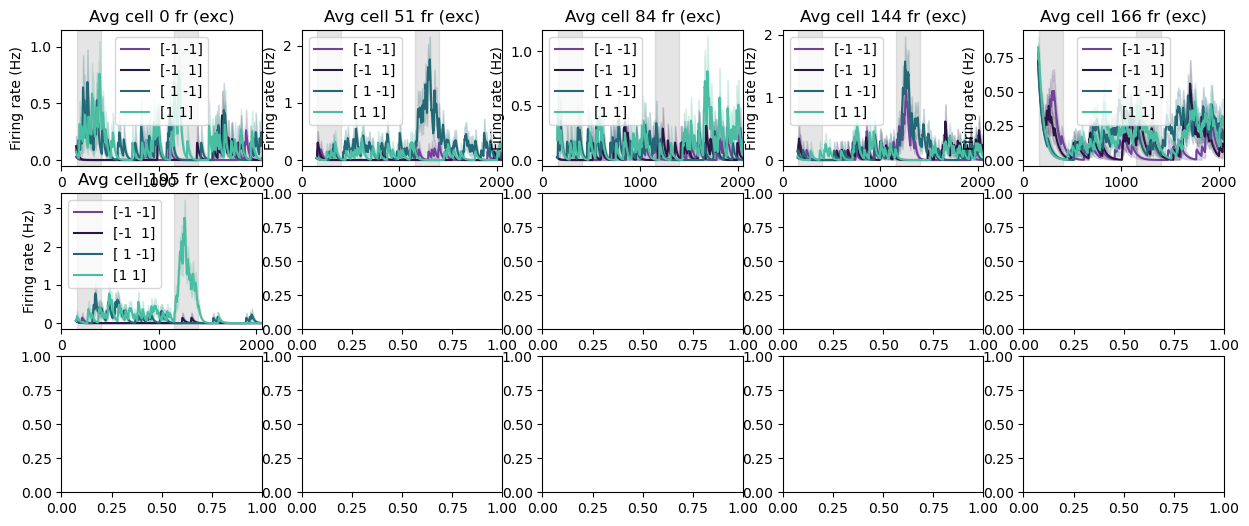

In [13]:
lowfr_idx = calc_lowfr_neurons(spk_df, times_spk, threshold=2)

fig, axs = plt.subplots(3,5, figsize=(15, 6))
axs = axs.flatten()
for i, i_neuron in enumerate(lowfr_idx):
    sn.plot_neuron_rates(model_name, i_neuron, condn_phrase, condn_num, 
                         rates_data=rates_data, ax=axs[i], cut_off=150)

In [14]:
lowfr_idx

array([  0,  51,  84, 144, 166, 195])

### delay=50

In [15]:
condn_num = 50

In [16]:
_, spk_df, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                    load_LFP=False, load_spikes=True, load_rates=True)

In [17]:
times_spk, _,_ = ld.get_times_dict('spk', condn_phrase, condn_num)
spk_df['total_spkcount'] = spk_df['spk_times'].apply(lambda spikes: sn.count_spikes(spikes, times_spk['stim1_on'], times_spk['T']))

In [19]:
lowfr_idx

array([], dtype=int64)

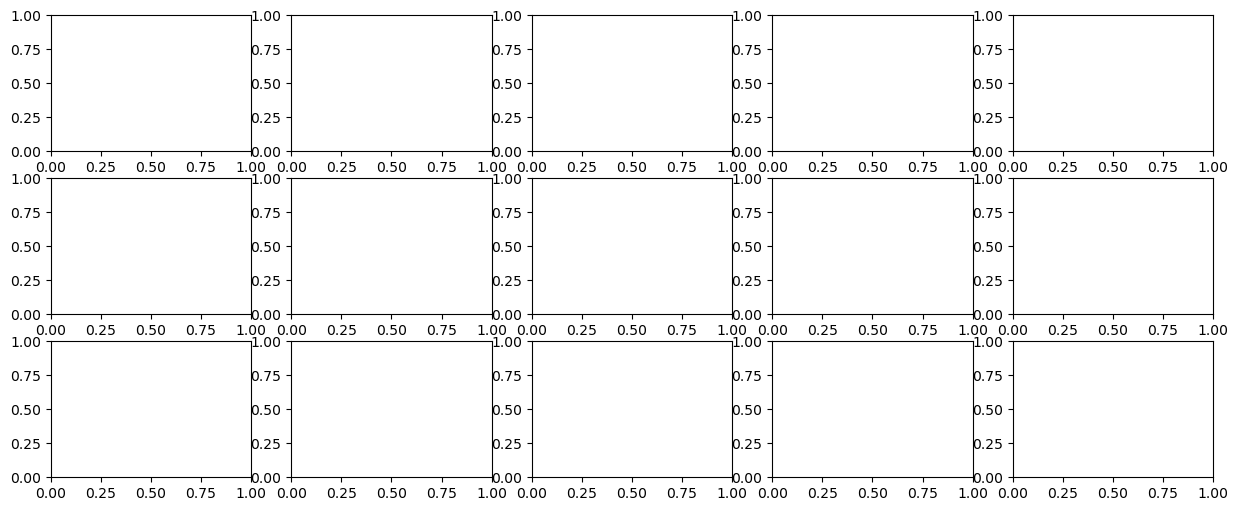

In [18]:
lowfr_idx = calc_lowfr_neurons(spk_df, times_spk, threshold=2)

fig, axs = plt.subplots(3,5, figsize=(15, 6))
axs = axs.flatten()
for i, i_neuron in enumerate(lowfr_idx):
    sn.plot_neuron_rates(model_name, i_neuron, condn_phrase, condn_num, 
                         rates_data=rates_data, ax=axs[i], cut_off=150)

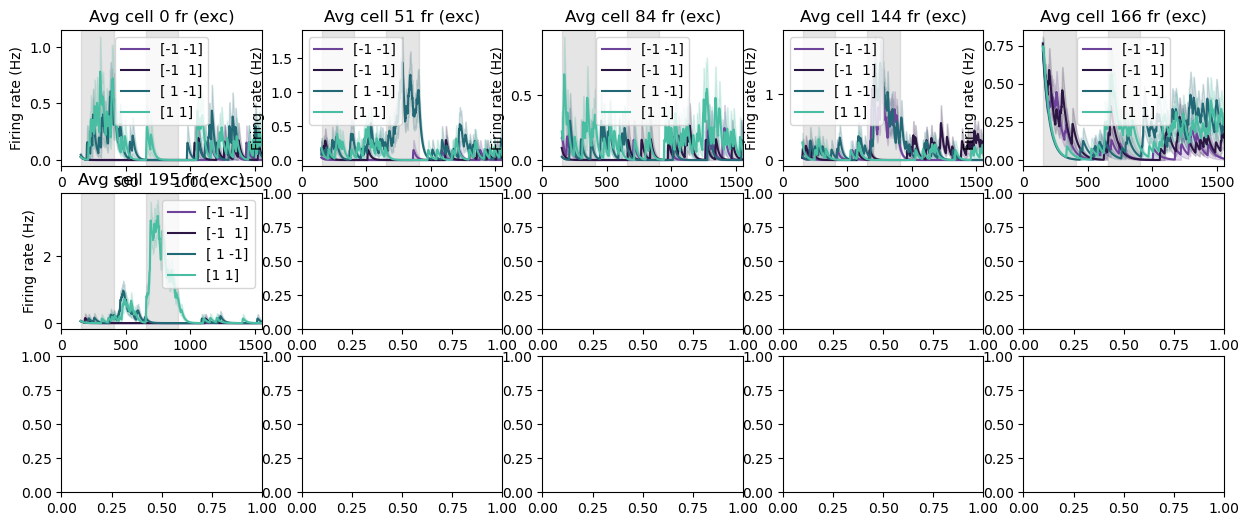

In [20]:
lowfr_idx = calc_lowfr_neurons(spk_df, times_spk, threshold=2)

fig, axs = plt.subplots(3,5, figsize=(15, 6))
axs = axs.flatten()
for i, i_neuron in enumerate([  0,  51,  84, 144, 166, 195]):
    sn.plot_neuron_rates(model_name, i_neuron, condn_phrase, condn_num, 
                         rates_data=rates_data, ax=axs[i], cut_off=150)

## repeat for many models

In [7]:
importlib.reload(ld)
def calc_lowfr_neurons(spk_df, times_spk, threshold=2):
    spk_df['total_spkcount'] = spk_df['spk_times'].apply(lambda spikes: sn.count_spikes(spikes, times_spk['stim1_on'], times_spk['T']))
    n_neurons = len(np.unique(spk_df['cell_id']))
    n_above_threshold = np.zeros(n_neurons)
    for i_neuron in range(n_neurons):
        neuron_df = spk_df[spk_df['cell_id'] == i_neuron]
        n_above_threshold[i_neuron] = np.sum(neuron_df['total_spkcount'] >= (times_spk['T']-times_spk['stim1_on'])/times_spk['fs'] * threshold)
        
    return np.where(n_above_threshold == 0)[0] # these neurons had no trials above desired fr threshold

In [23]:
lowfr_idx = calc_lowfr_neurons(spk_df, times_spk, threshold=2)
lowfr_idx

array([ 14,  24,  65, 132, 138, 193, 197])

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645 has 22 low firing rate neurons


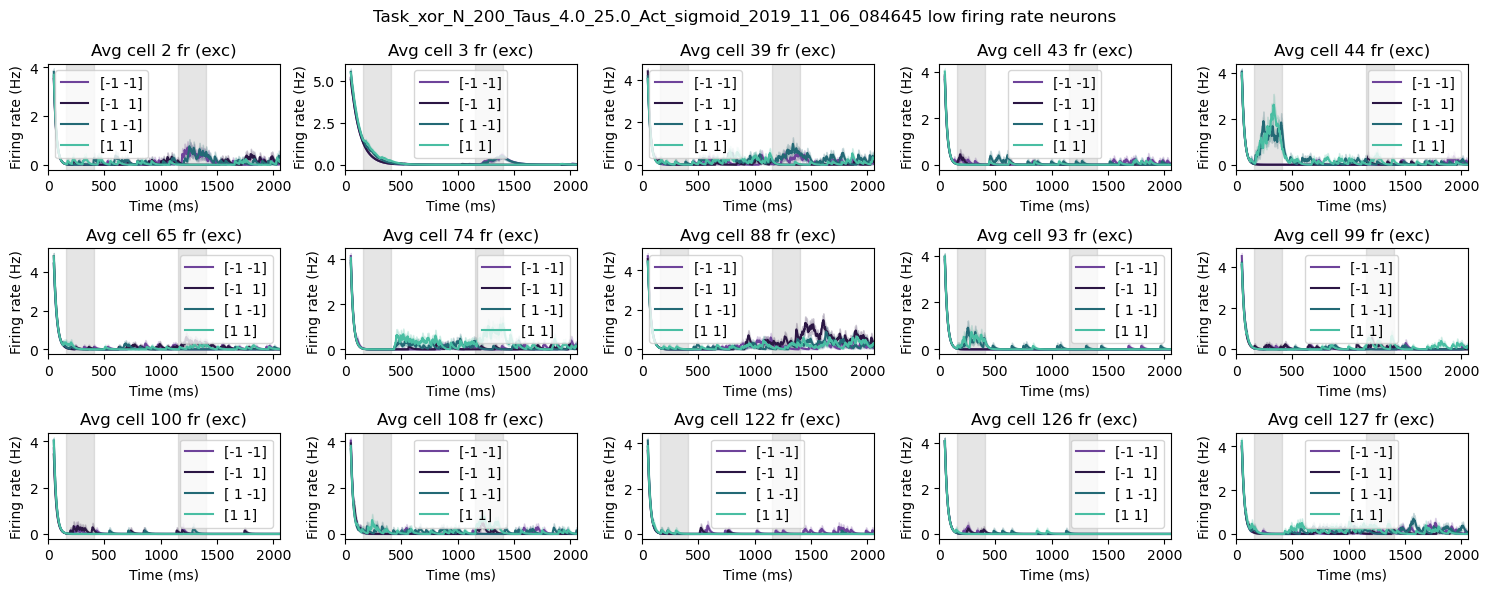

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926 has 4 low firing rate neurons


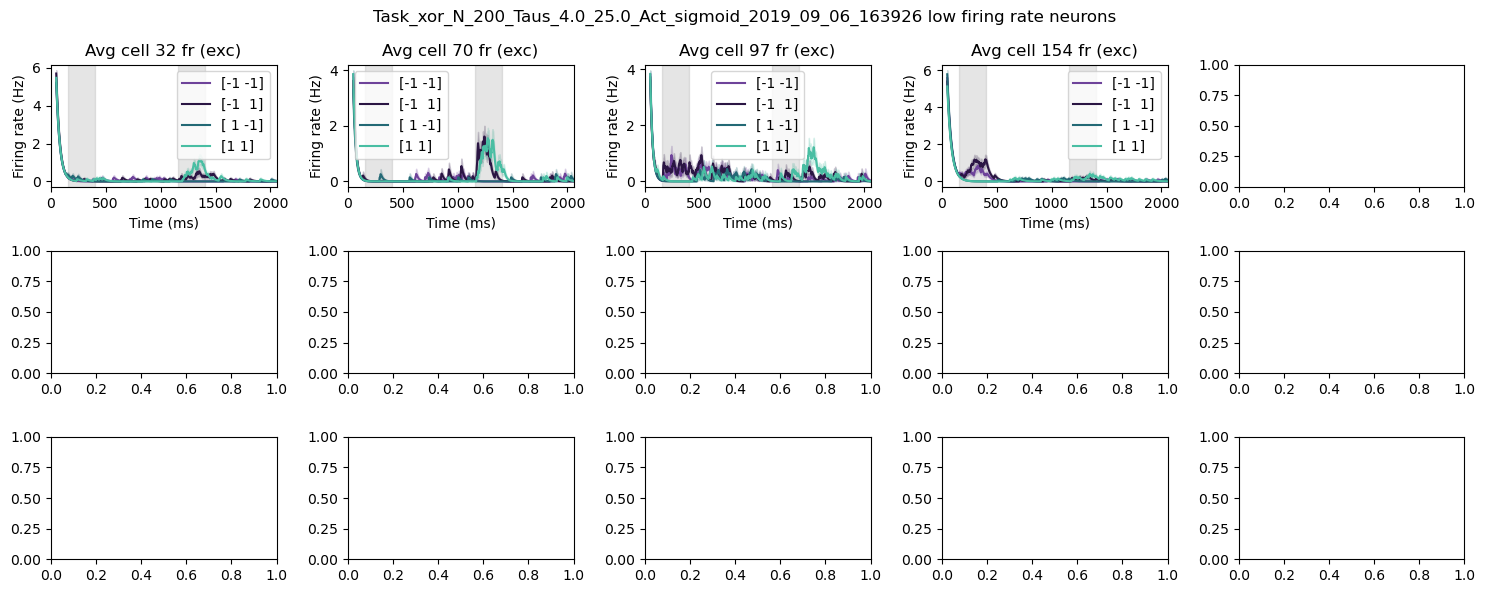

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648 has 12 low firing rate neurons


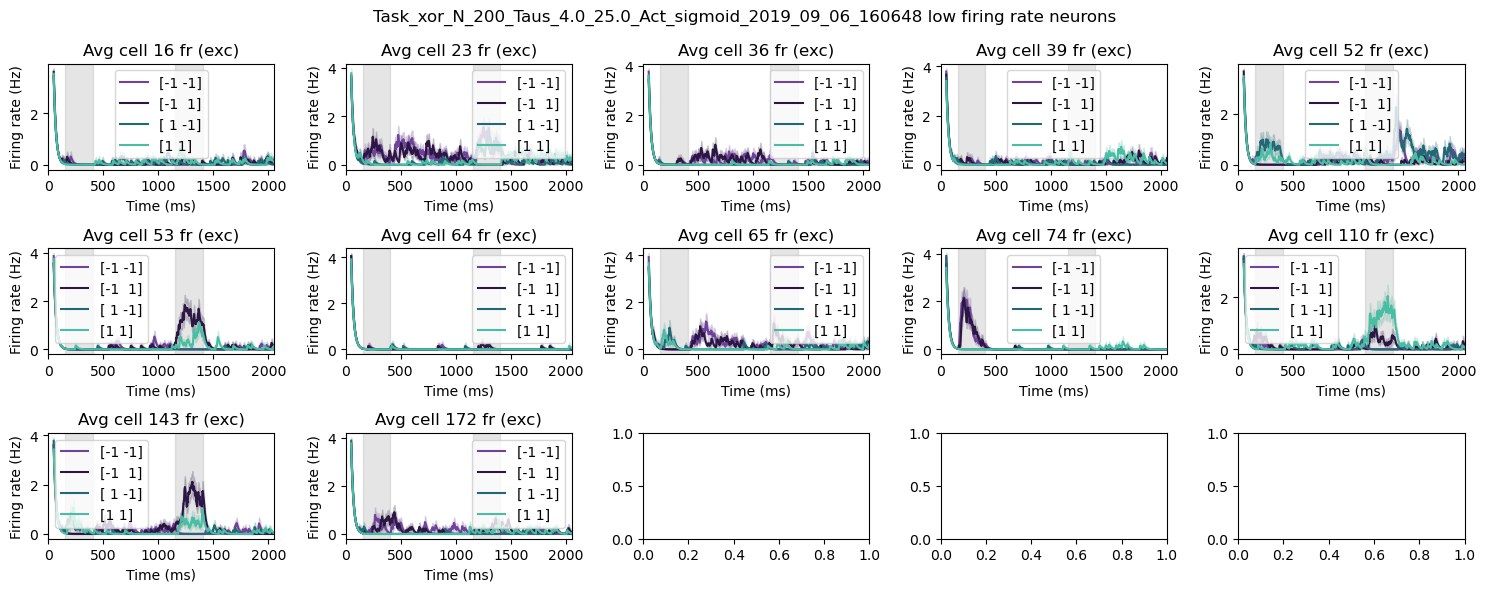

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449 has 12 low firing rate neurons


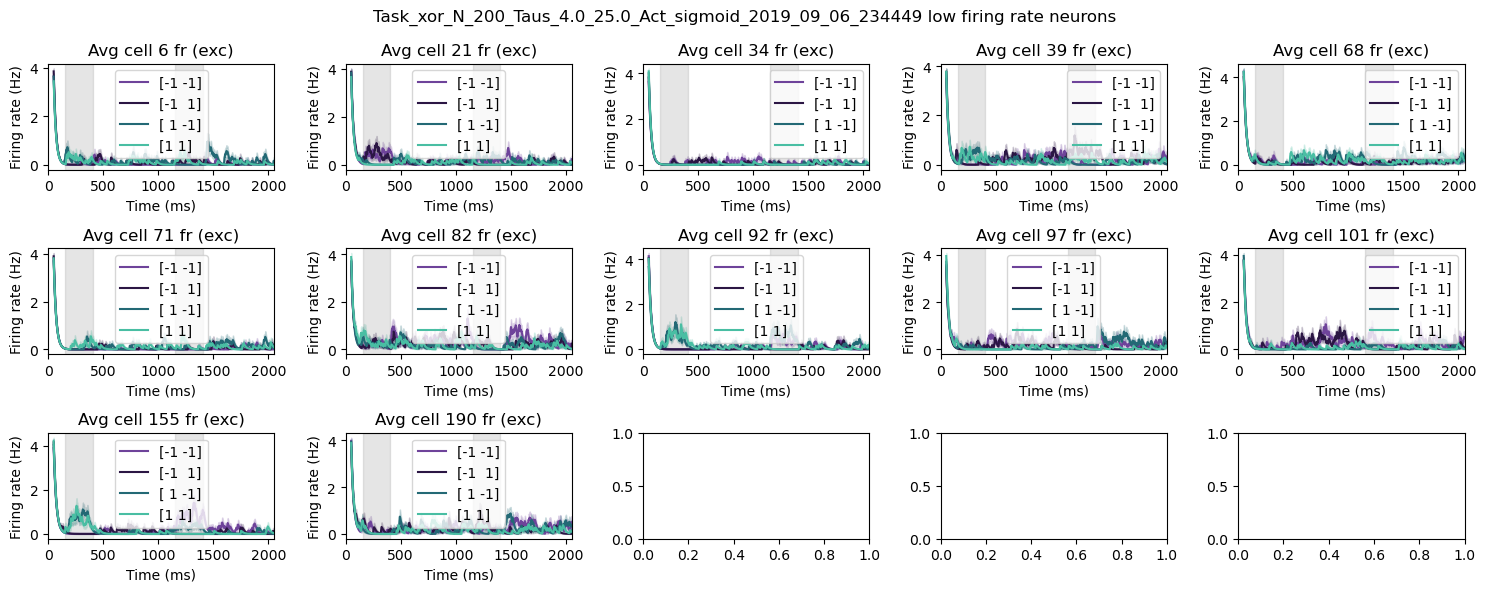

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_040139 has 10 low firing rate neurons


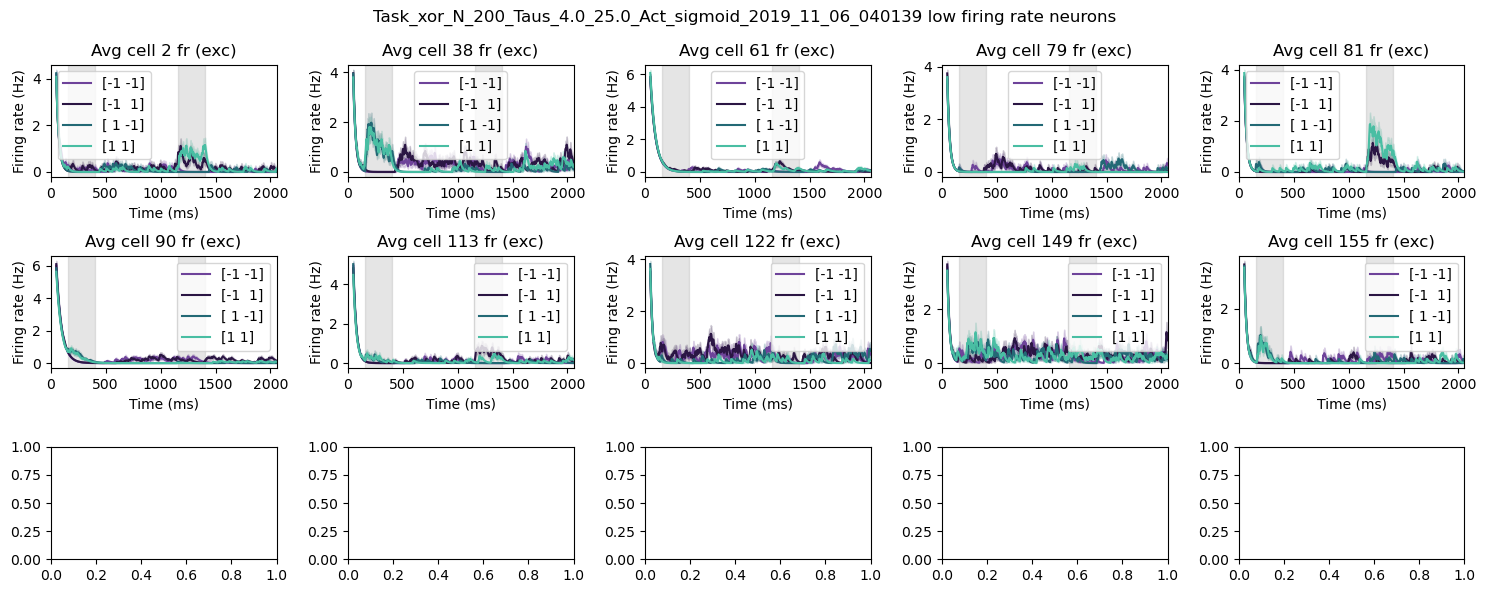

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032959 has 38 low firing rate neurons


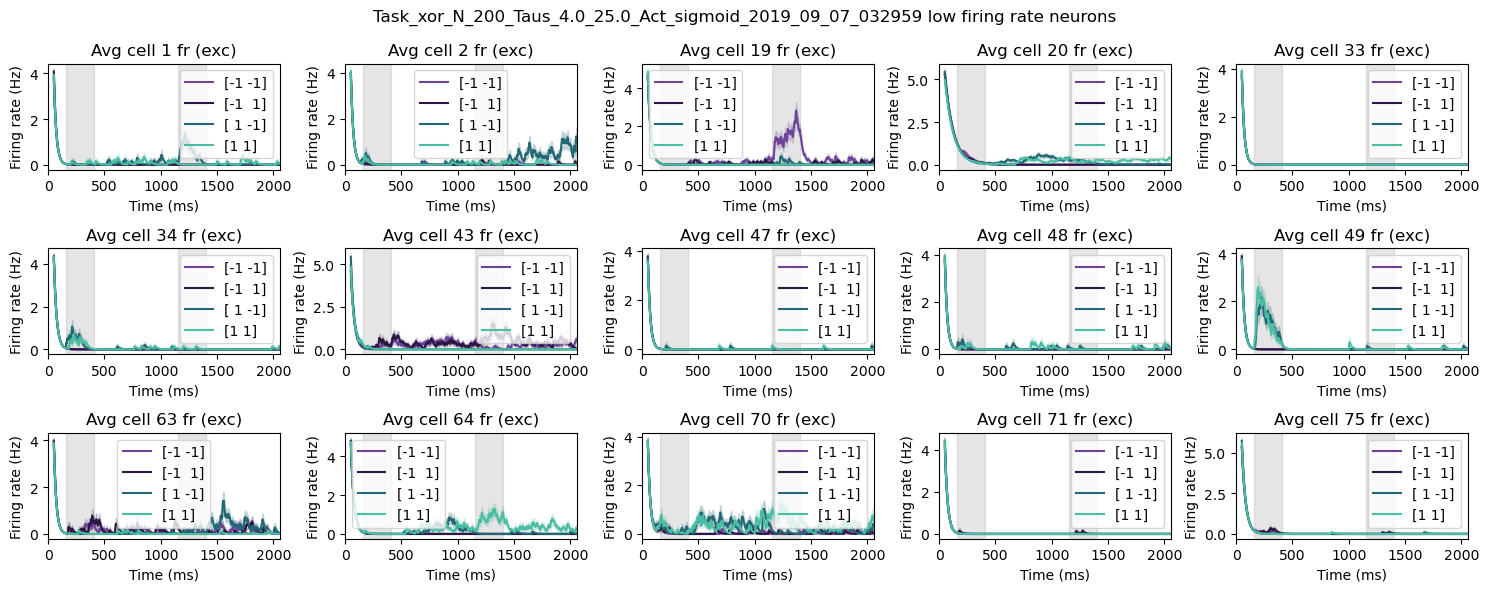

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_080217 has 4 low firing rate neurons


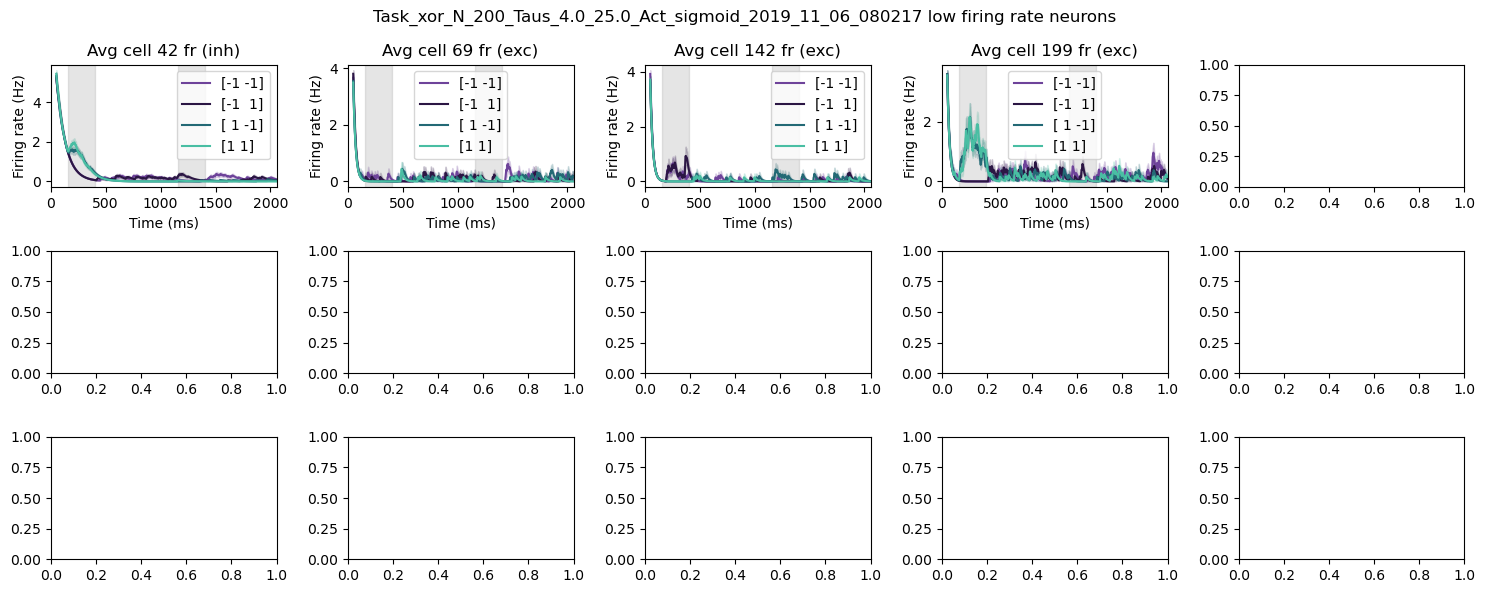

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_191643 has 11 low firing rate neurons


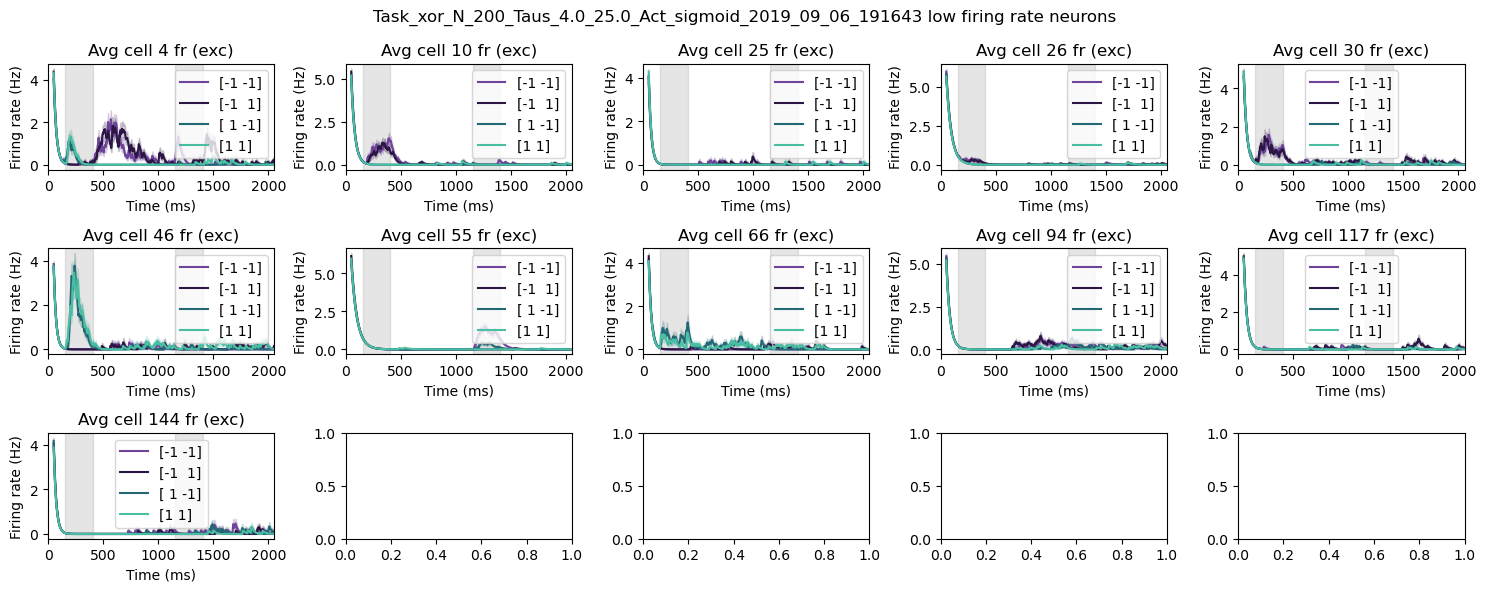

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906 has 5 low firing rate neurons


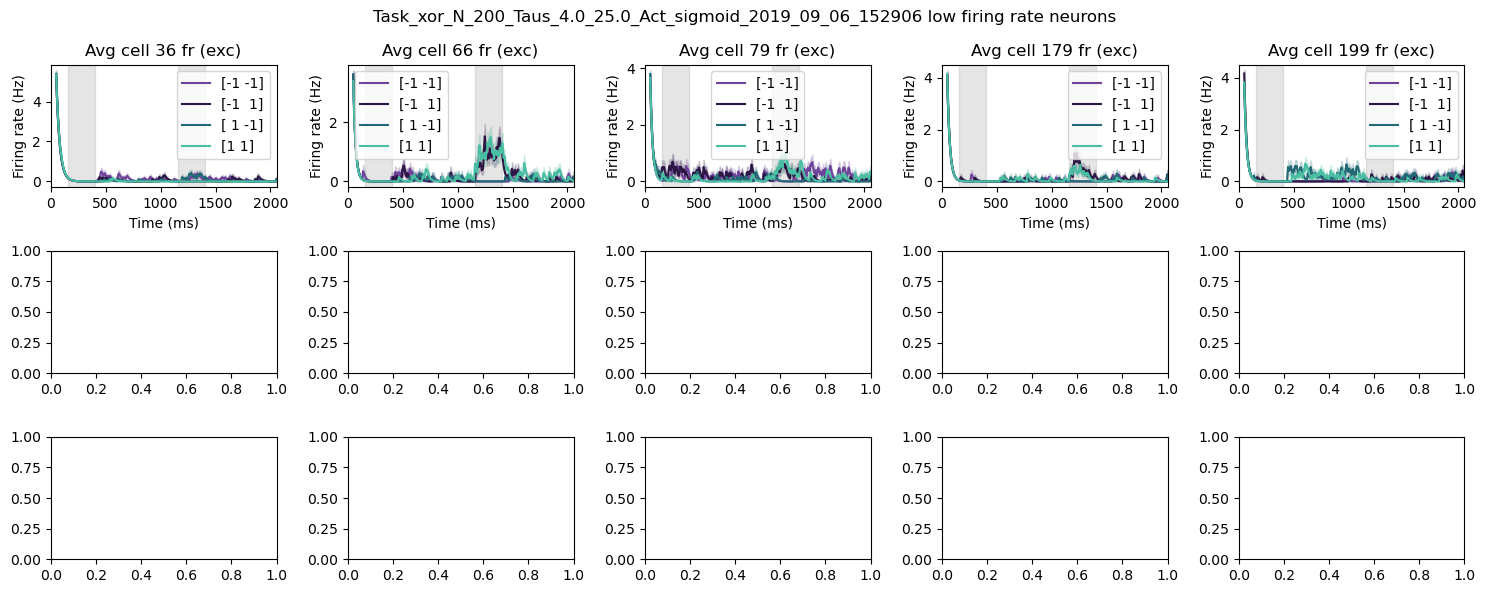

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_004449 has 23 low firing rate neurons


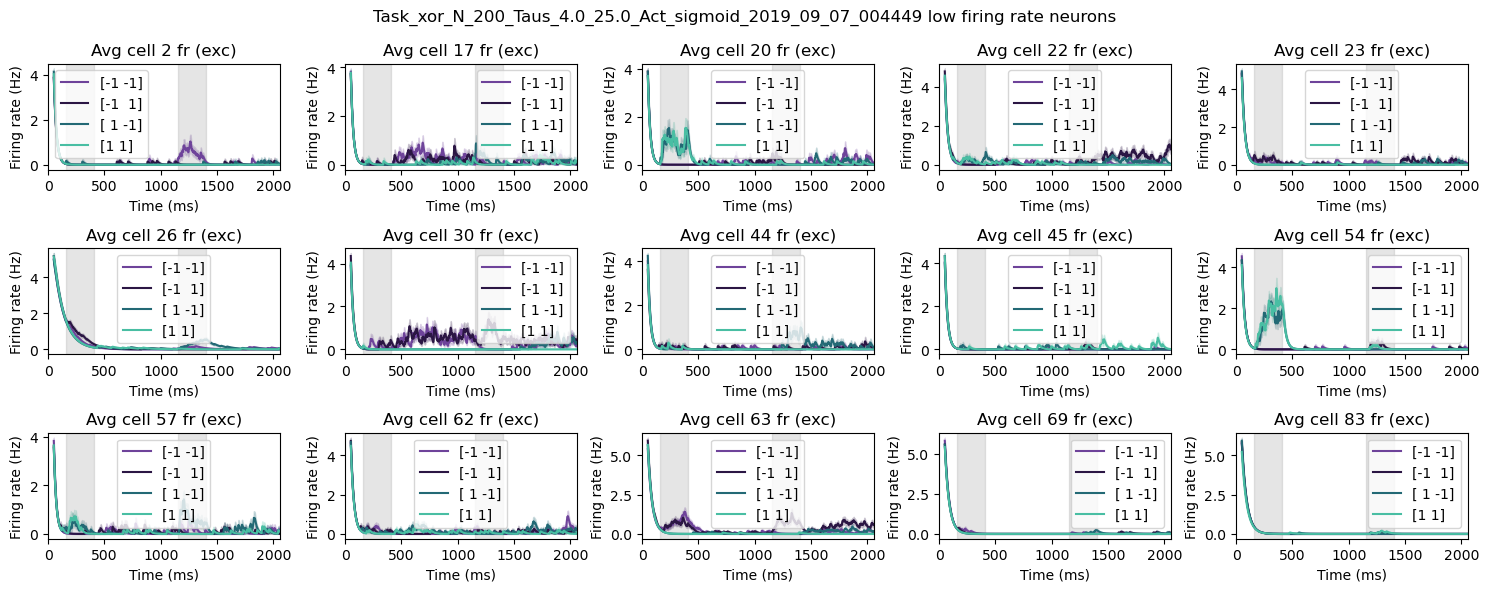

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_191340 has 70 low firing rate neurons


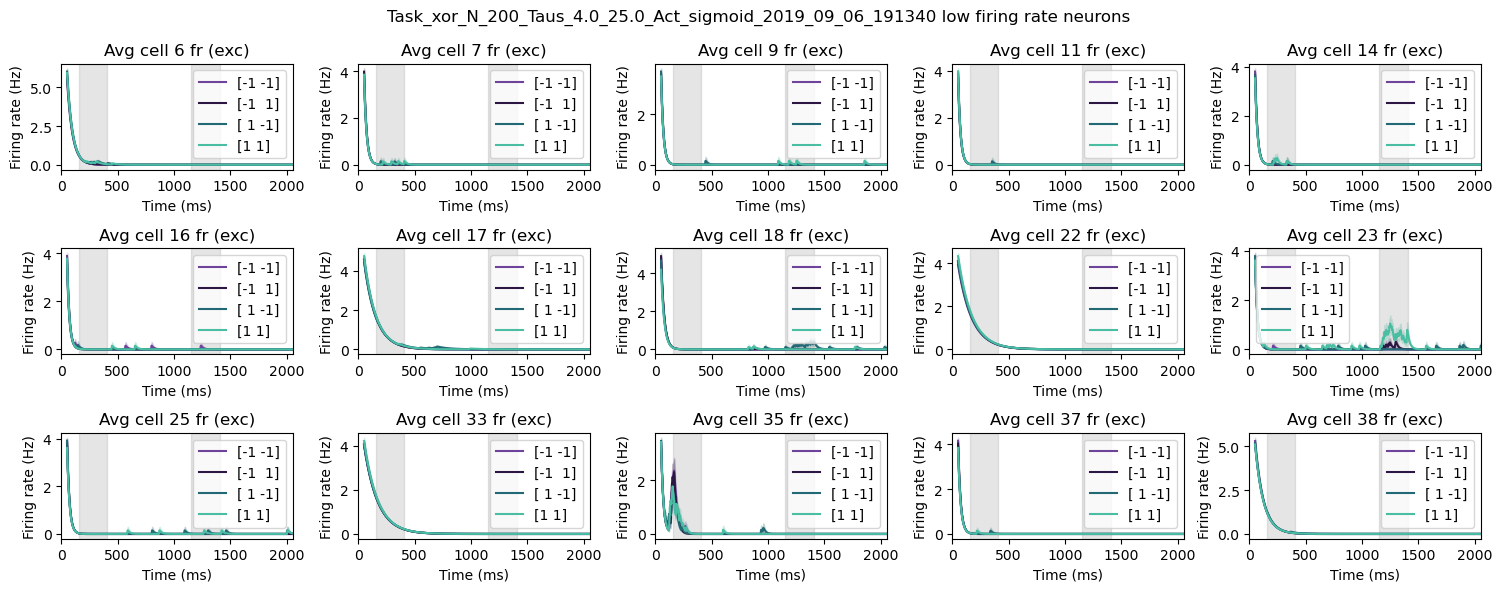

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_002808 has 0 low firing rate neurons


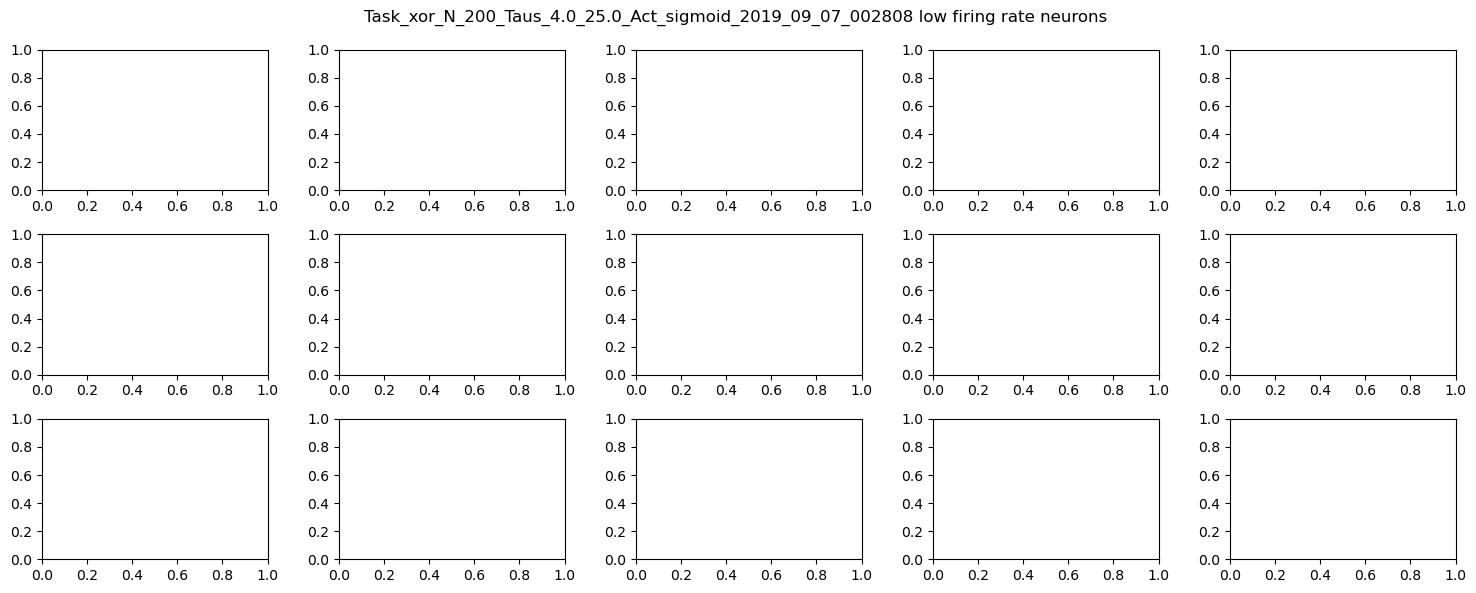

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_134839 has 4 low firing rate neurons


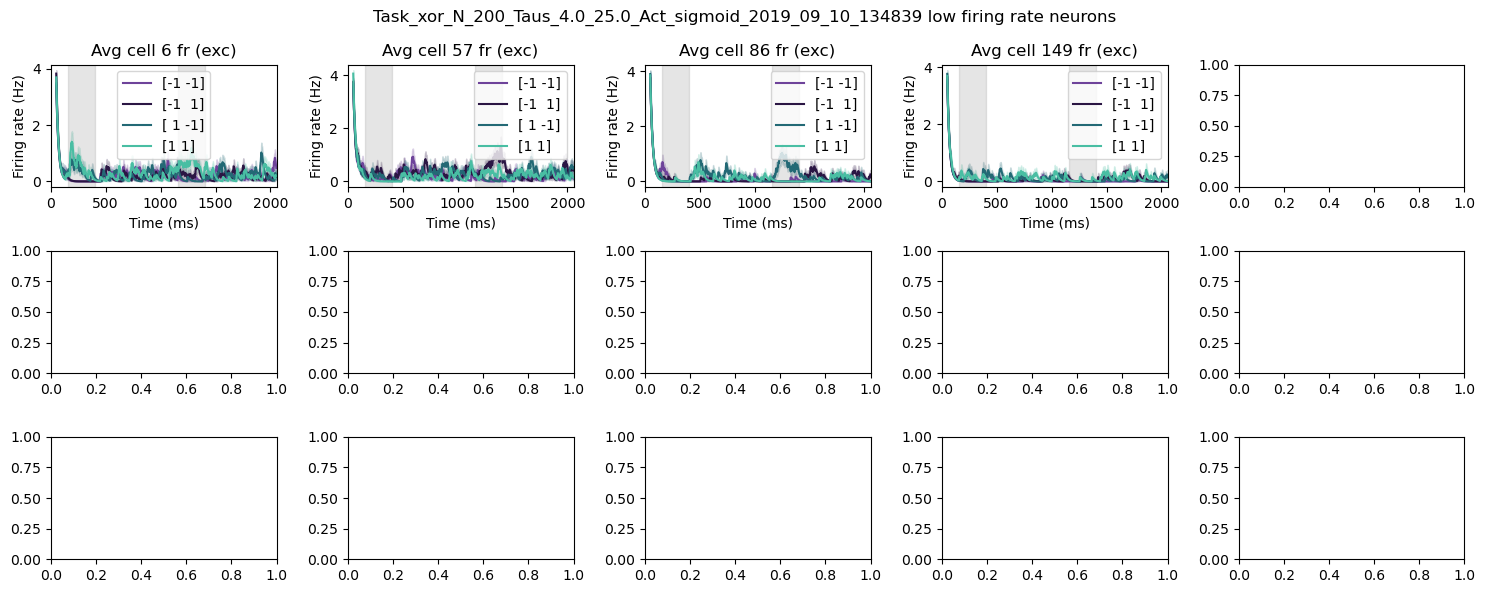

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_123338 has 5 low firing rate neurons


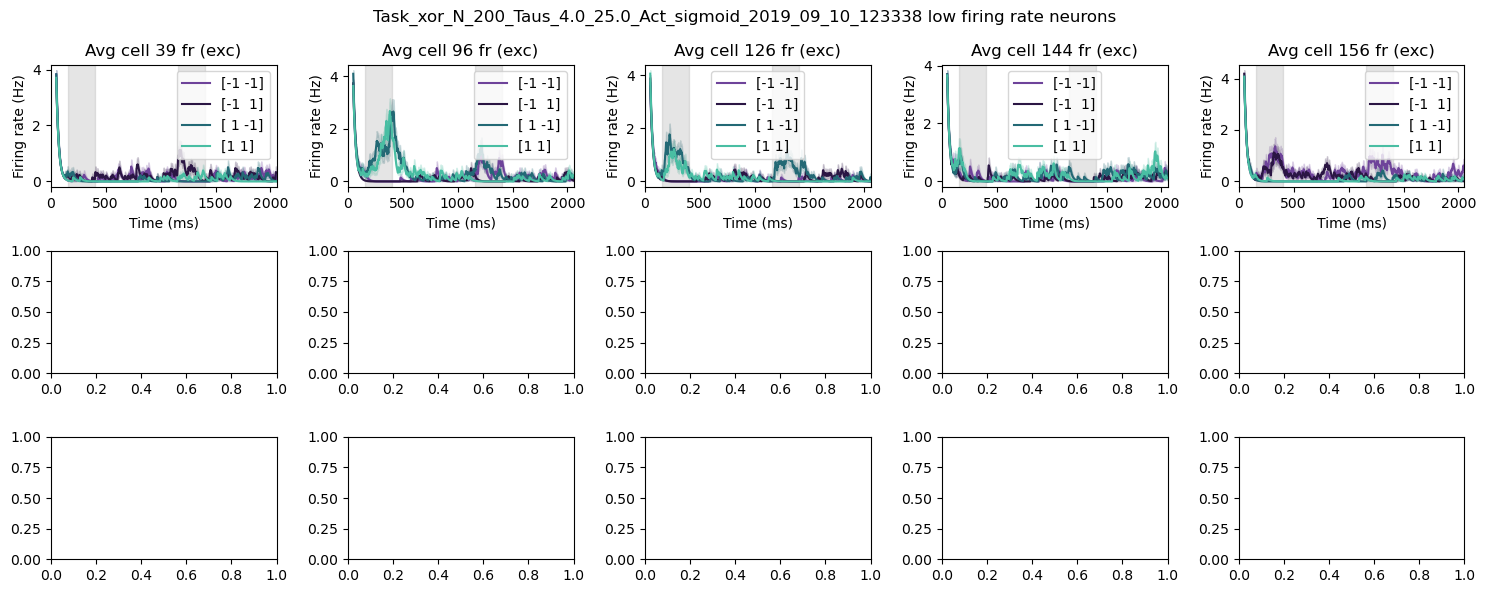

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_125124 has 18 low firing rate neurons


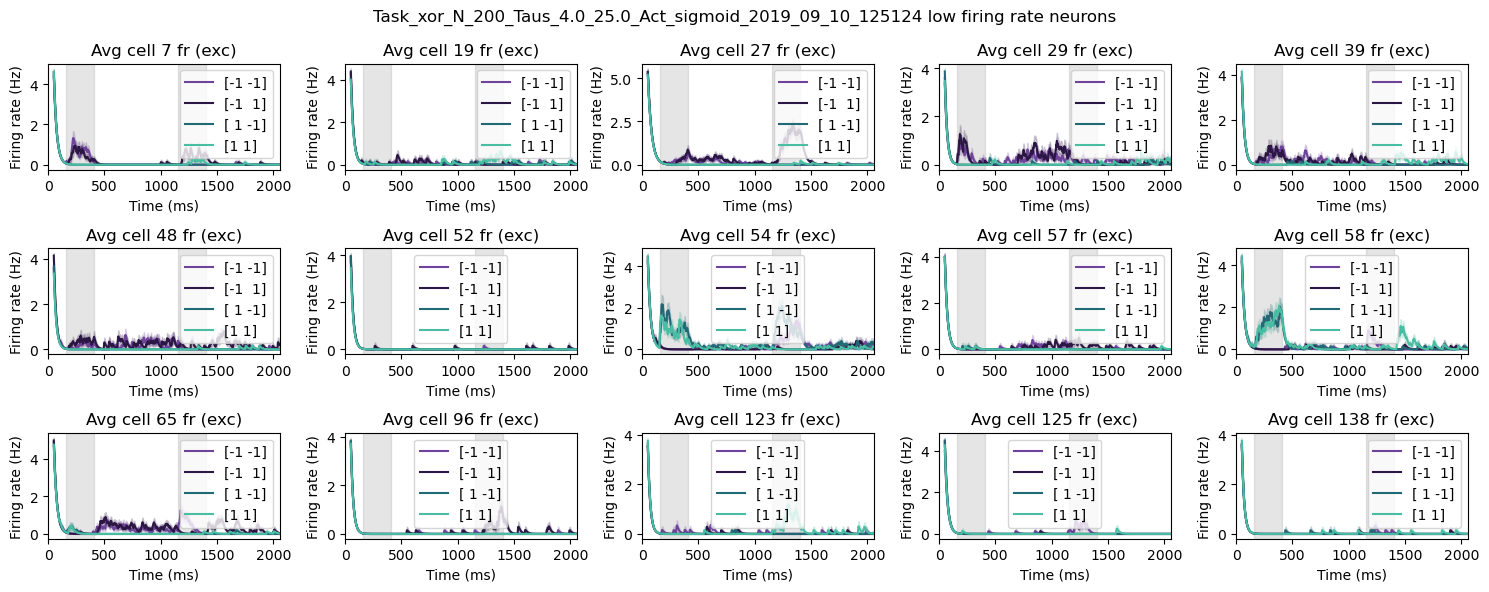

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204500 has 13 low firing rate neurons


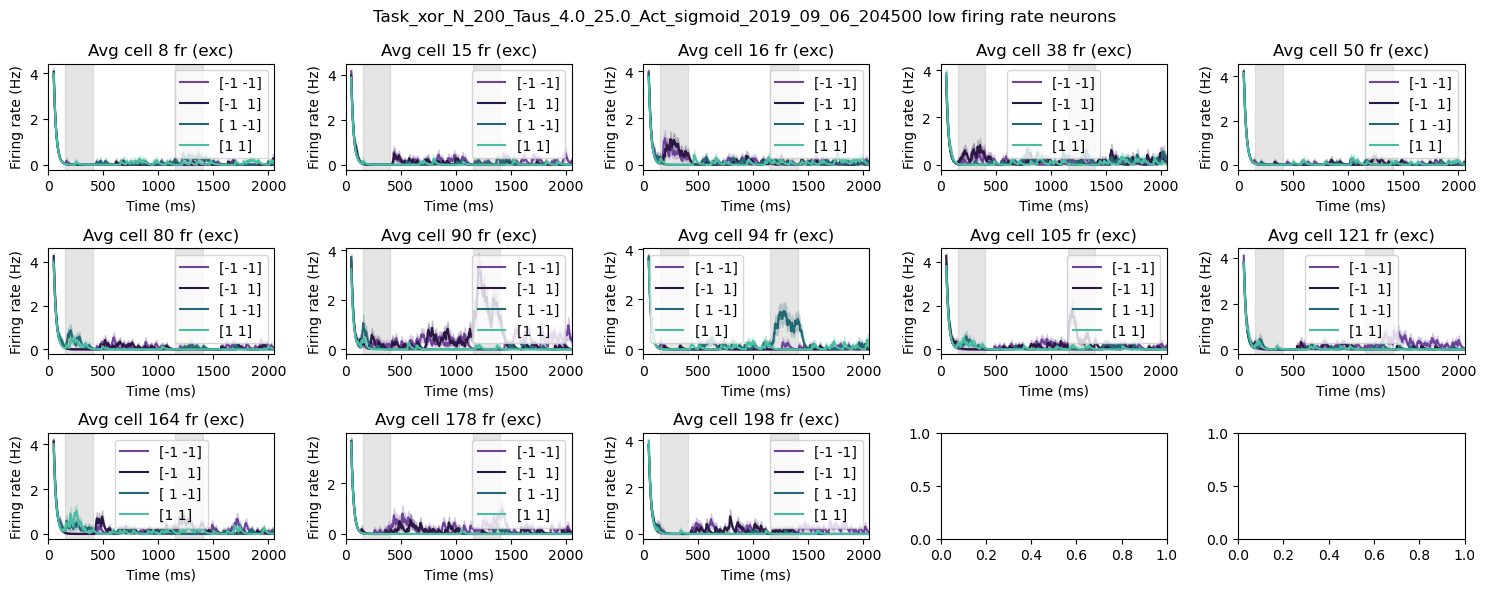

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_041124 has 13 low firing rate neurons


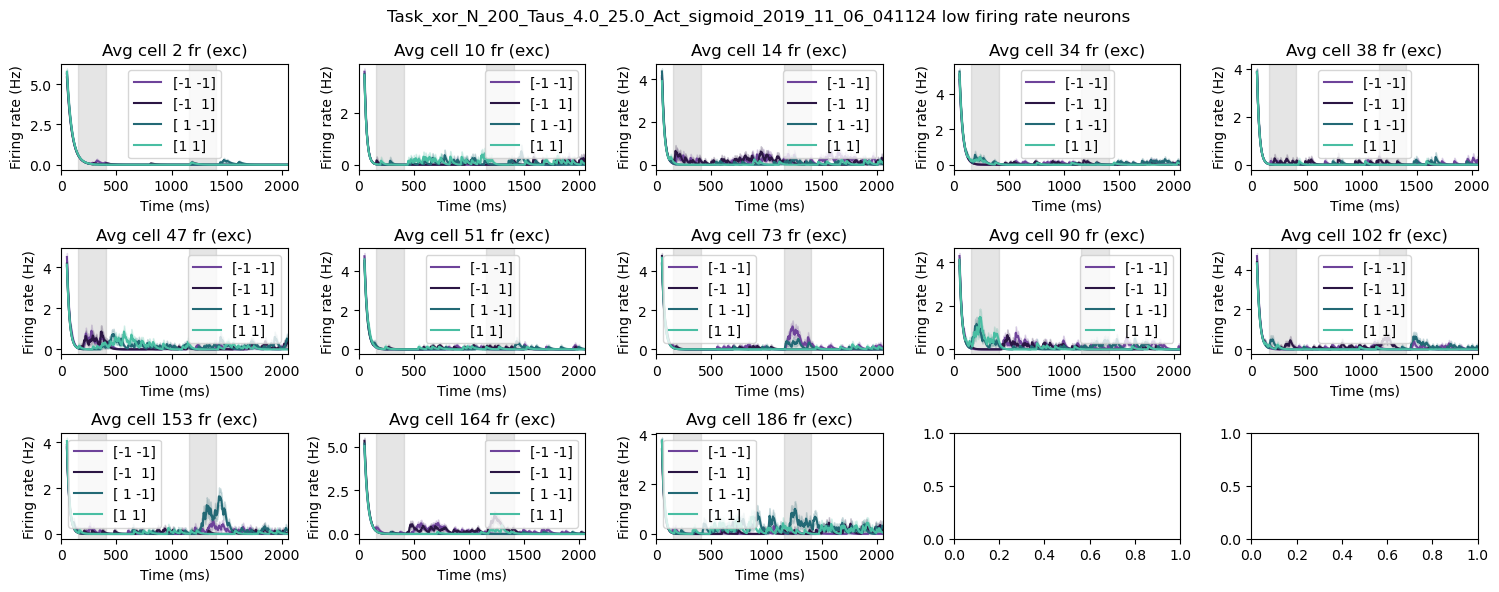

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_101718 has 14 low firing rate neurons


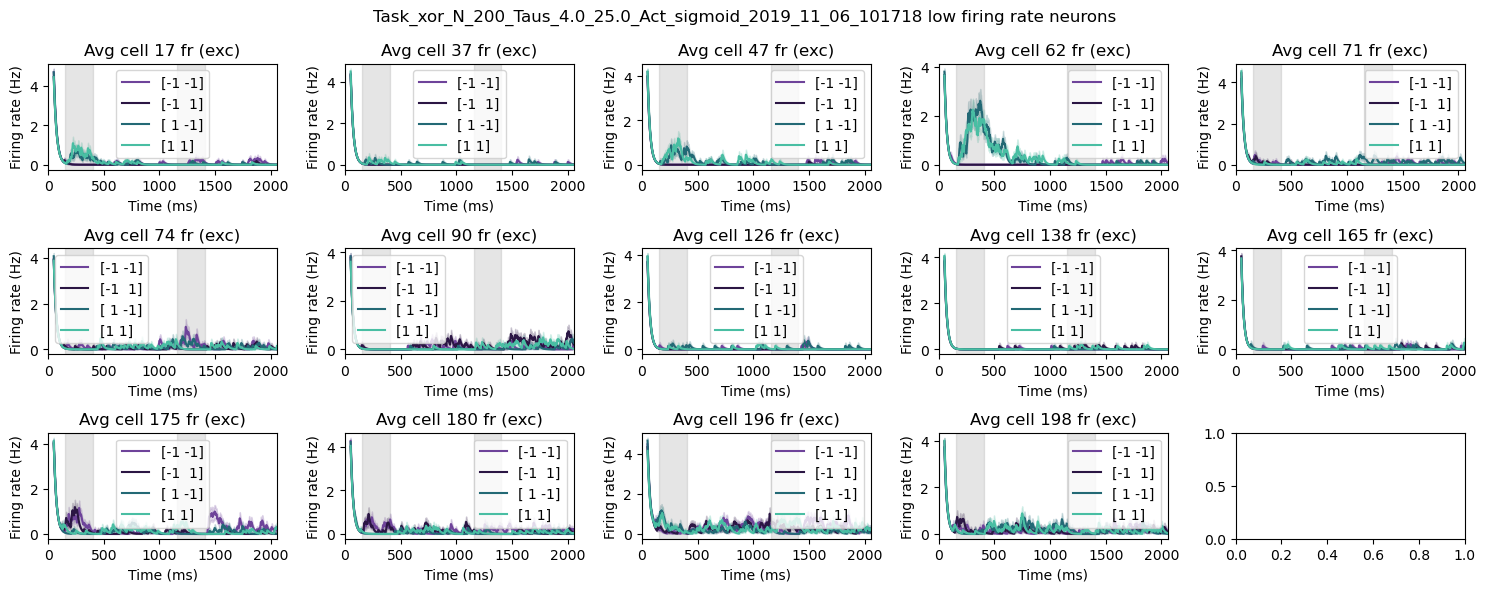

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_075450 has 13 low firing rate neurons


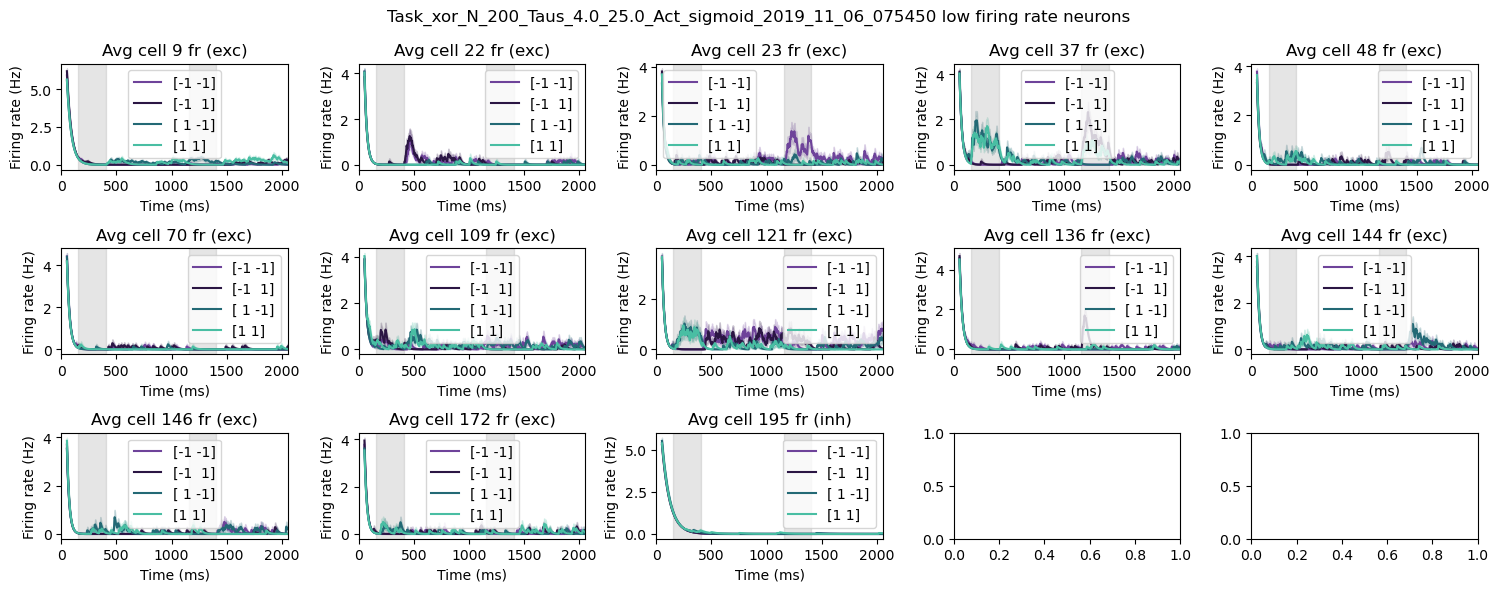

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_190737 has 40 low firing rate neurons


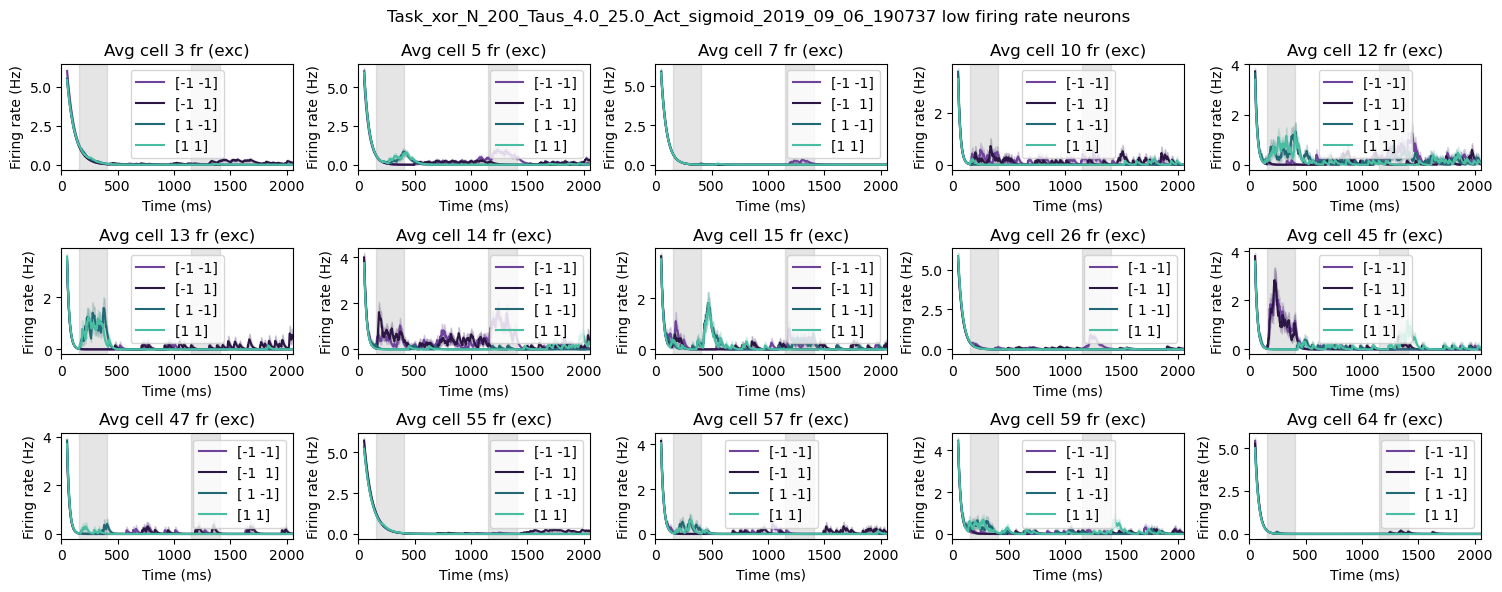

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_055819 has 11 low firing rate neurons


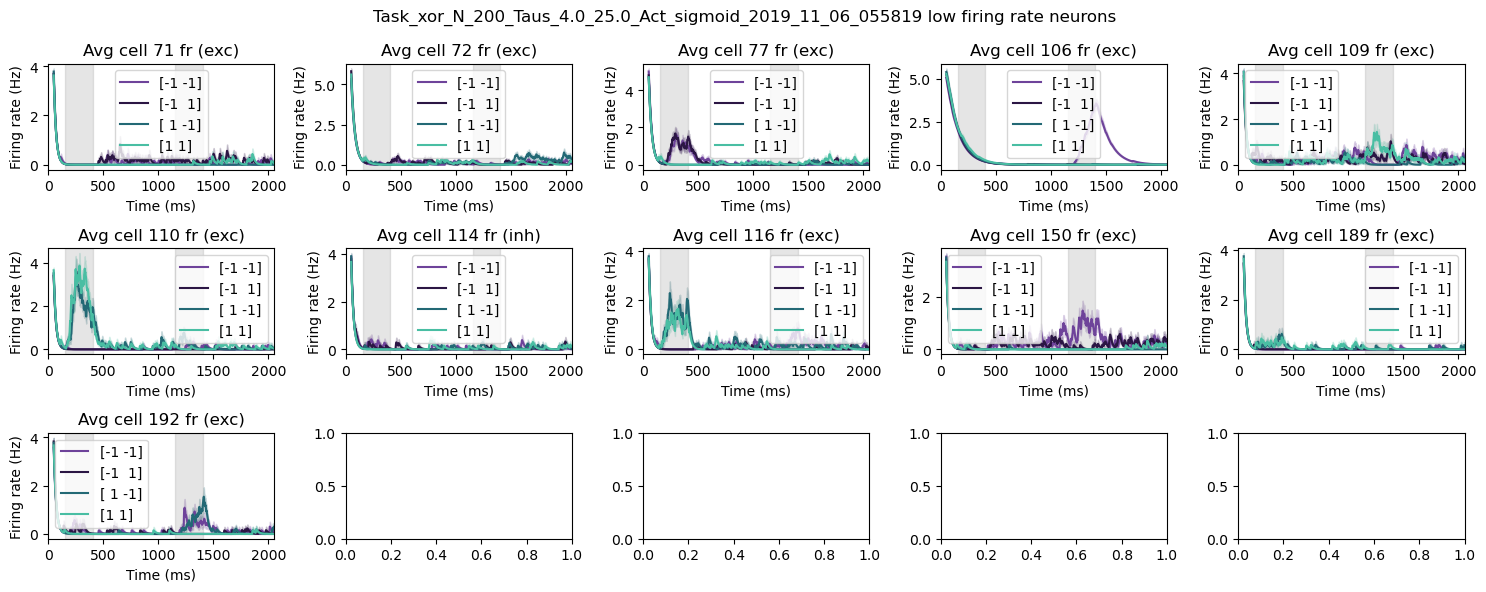

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_005938 has 49 low firing rate neurons


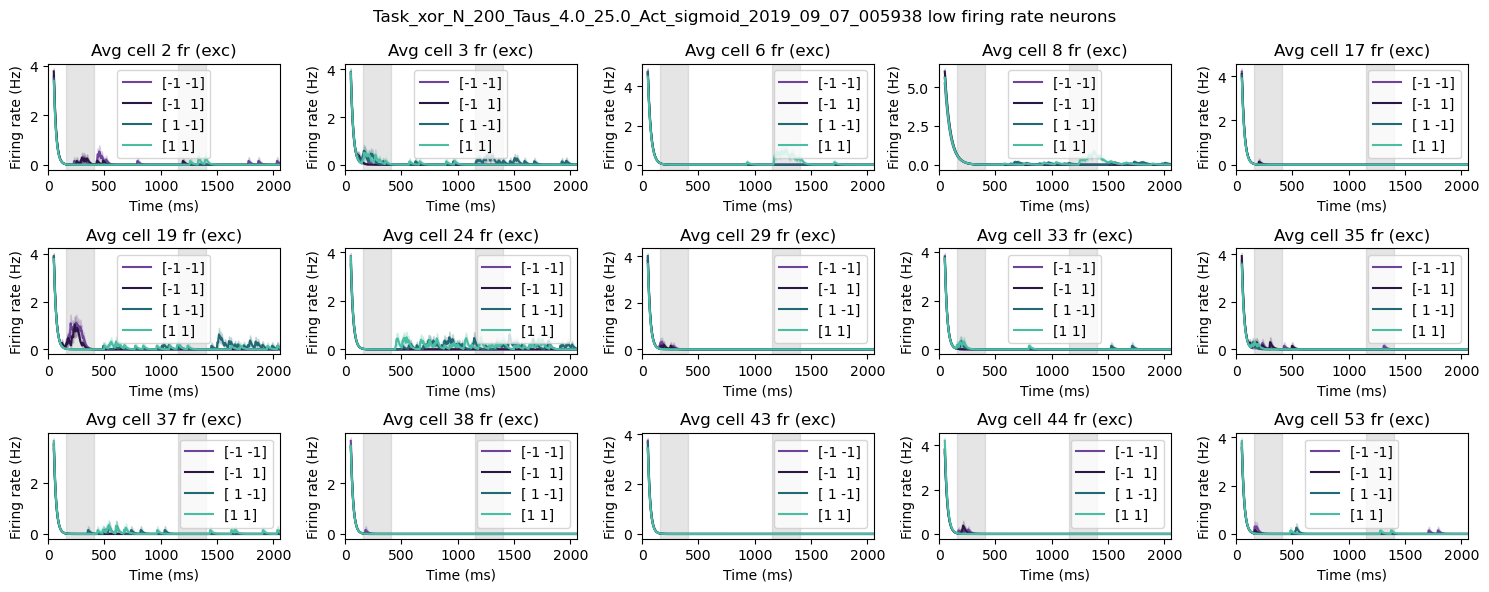

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_015655 has 12 low firing rate neurons


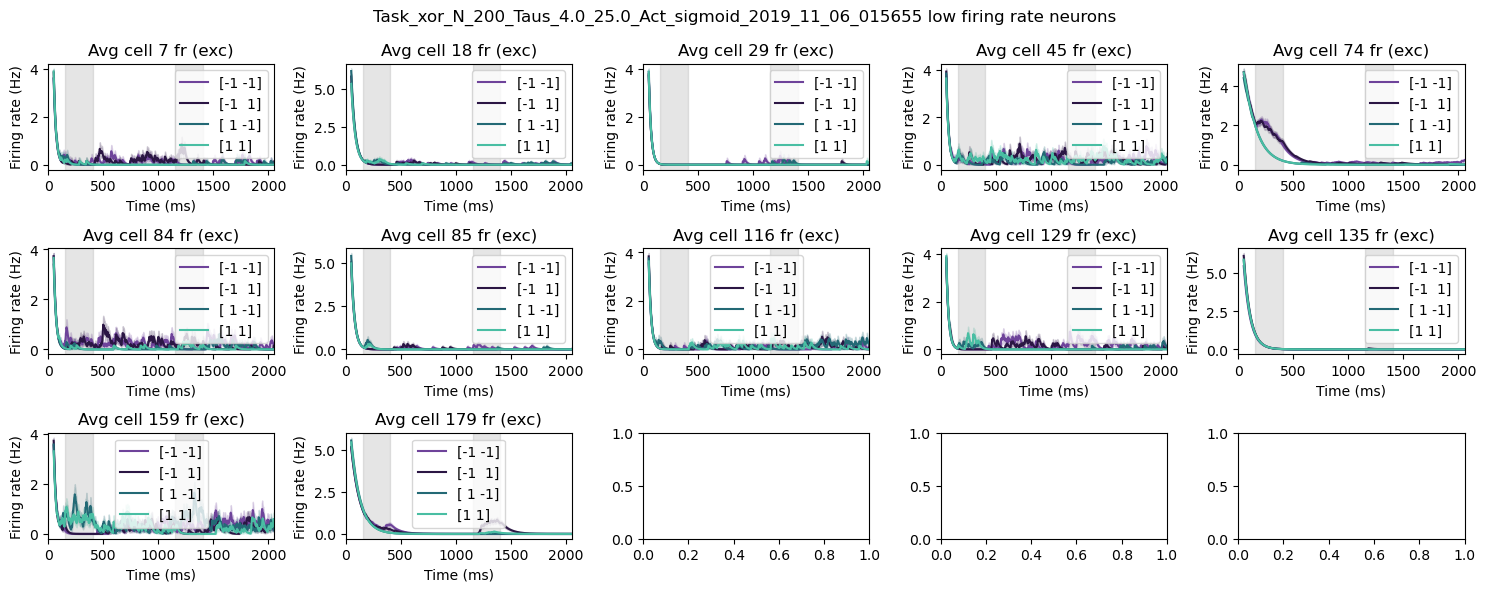

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_220028 has 36 low firing rate neurons


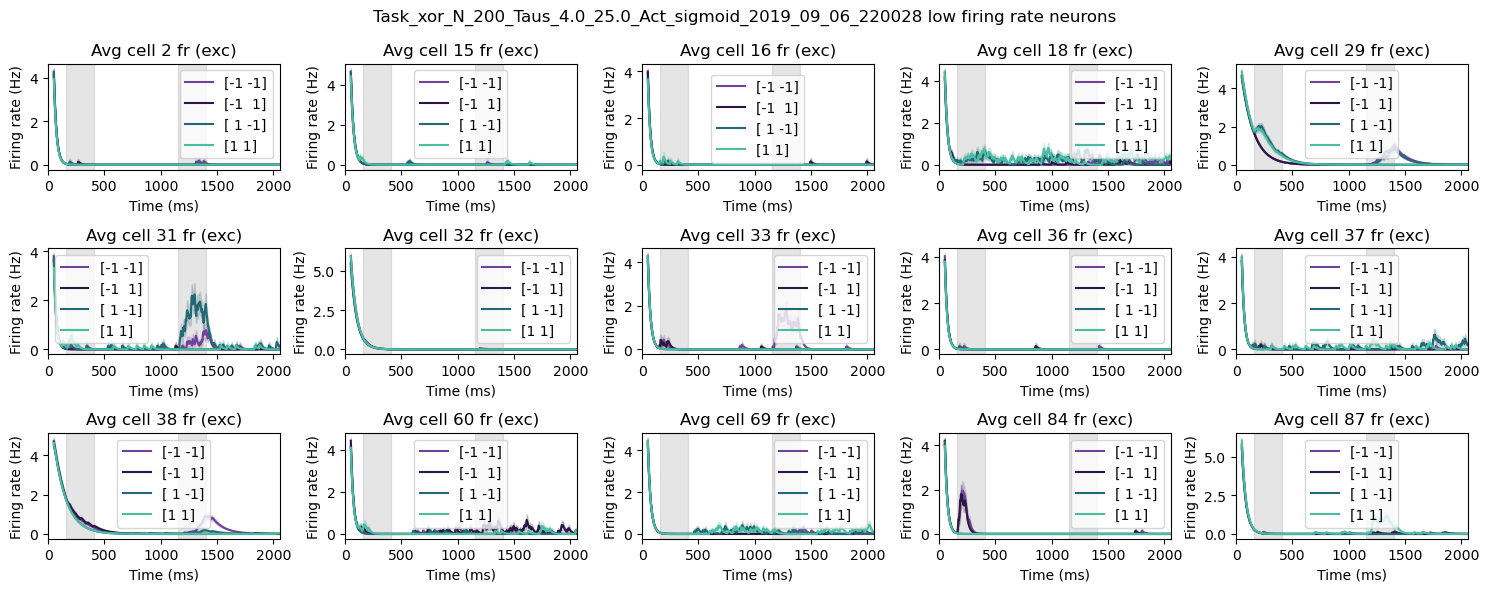

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_012954 has 17 low firing rate neurons


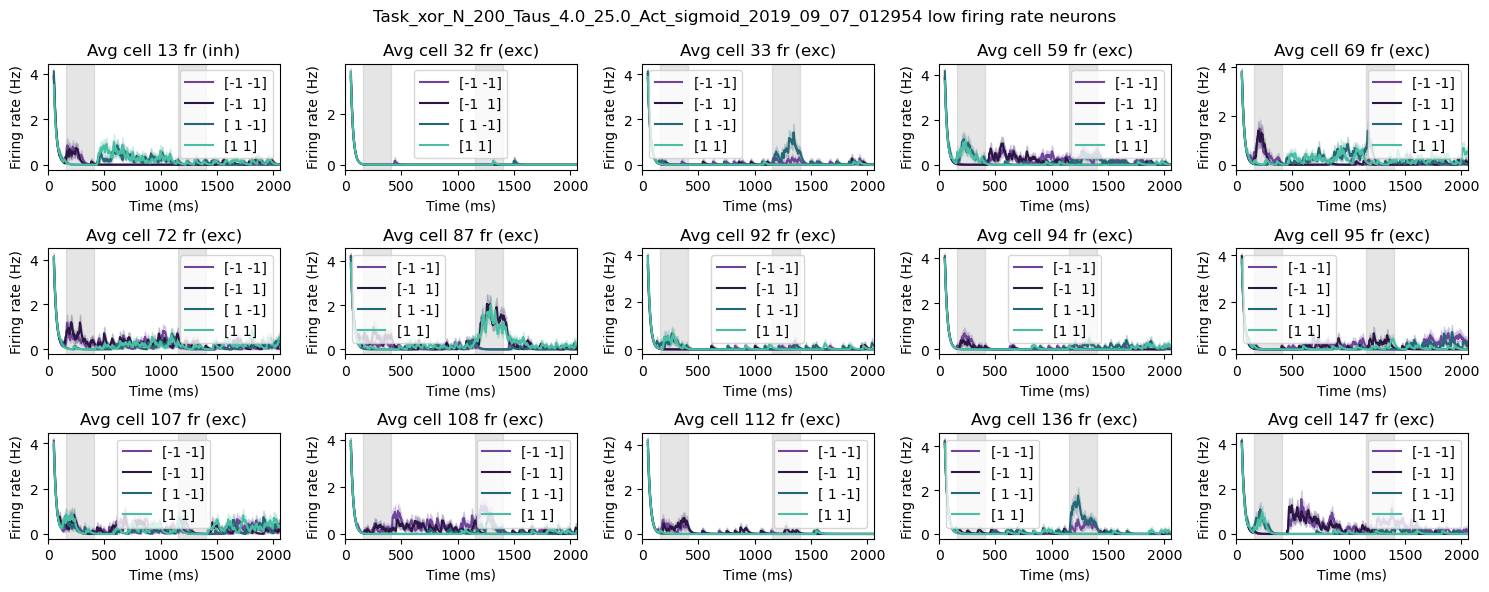

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_170345 has 16 low firing rate neurons


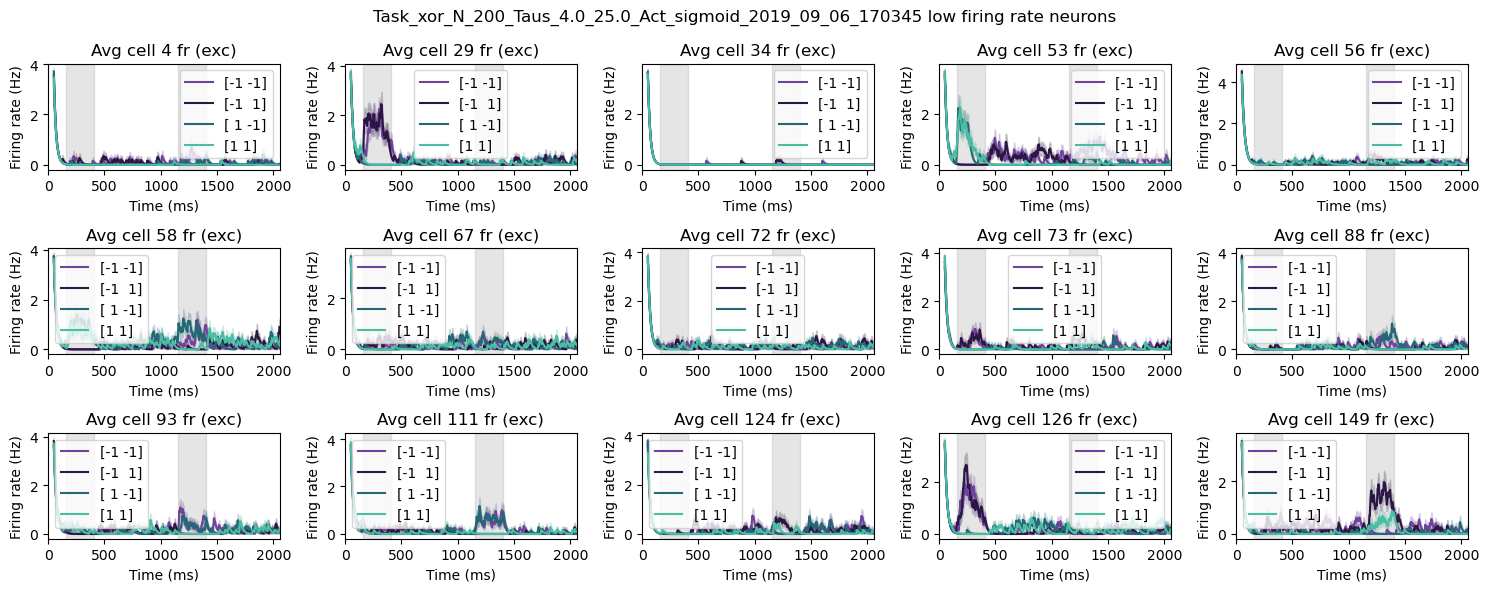

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_045851 has 5 low firing rate neurons


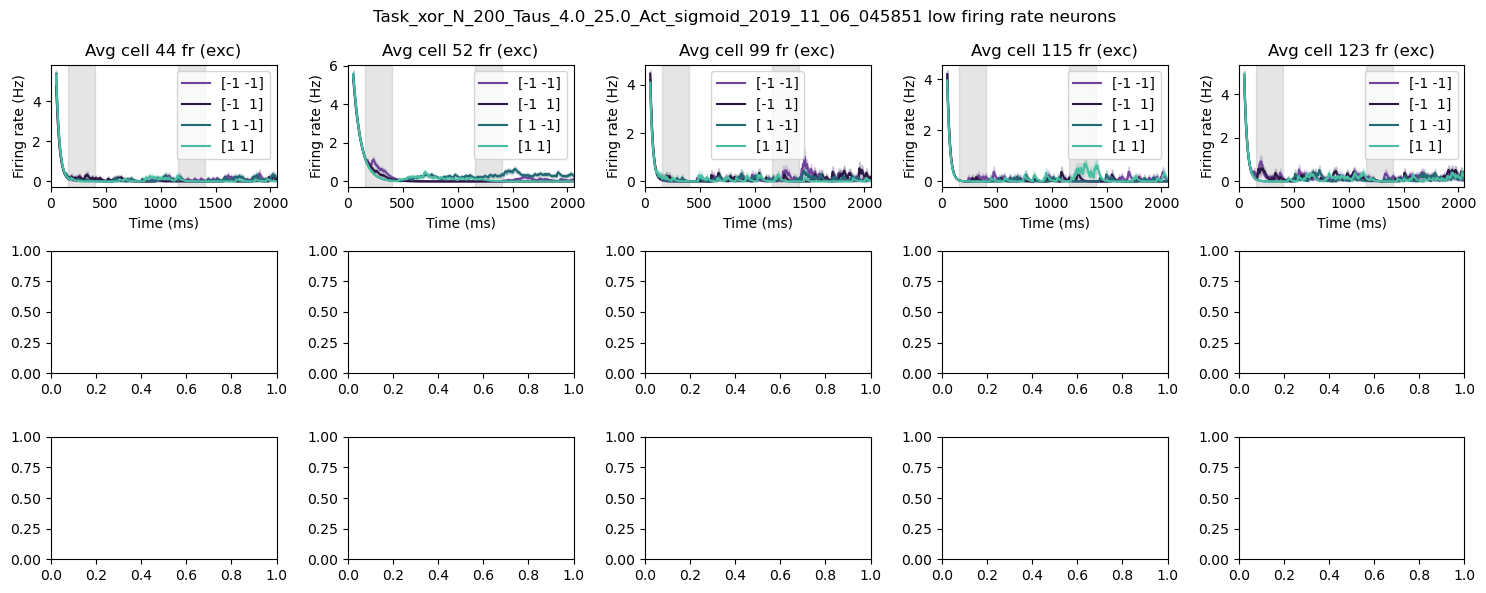

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_180429 has 7 low firing rate neurons


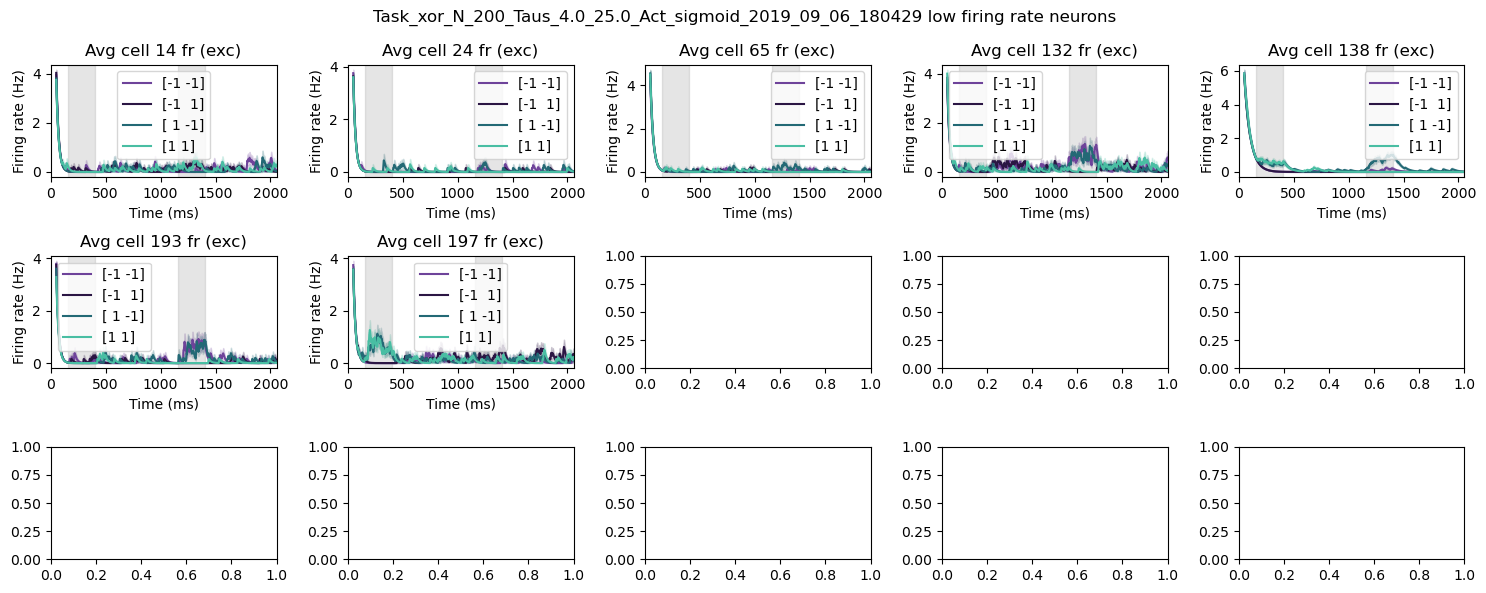

In [18]:
n_lowfr_2 = np.zeros(len(bad_models))
for i_model, model_name in enumerate(bad_models):
    _, spk_df, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                    load_LFP=False, load_spikes=True, load_rates=True)
    times_spk, _,_ = ld.get_times_dict('spk', condn_phrase, condn_num)
    lowfr_idx = calc_lowfr_neurons(spk_df, times_spk, threshold=2)
    n_lowfr_2[i_model] = len(lowfr_idx)
    print(f'{model_name} has {len(lowfr_idx)} low firing rate neurons')
    
    fig, axs = plt.subplots(3,5, figsize=(15, 6))
    axs = axs.flatten()
    for i, i_neuron in enumerate(lowfr_idx):
        if i >= len(axs):
            continue
        sn.plot_neuron_rates(model_name, i_neuron, condn_phrase, condn_num, rates_data=rates_data, ax=axs[i])
    plt.suptitle(f'{model_name} low firing rate neurons')
    plt.tight_layout()
    plt.show()

In [17]:
plt.hist(n_lowfr_2, bins=np.arange(0, 80, 1))
plt.xlabel('Number of low firing rate neurons')
plt.ylabel('Number of models')
plt.title('Distribution of low firing rate neurons (<2Hz) across bad models')
plt.axvline(np.mean(n_lowfr_2), color='red', linestyle='--', label='Mean')
plt.legend()
plt.show()

NameError: name 'n_lowfr' is not defined

### threshold 1Hz

In [15]:
n_lowfr_1 = np.zeros(len(bad_models))
for i_model, model_name in enumerate(bad_models):
    _, spk_df, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                    load_LFP=False, load_spikes=True, load_rates=True)
    times_spk, _,_ = ld.get_times_dict('spk', condn_phrase, condn_num)
    lowfr_idx = calc_lowfr_neurons(spk_df, times_spk, threshold=1)
    n_lowfr_1[i_model] = len(lowfr_idx)
    print(f'{model_name} has {len(lowfr_idx)} low firing rate neurons')
    
    # fig, axs = plt.subplots(3,5, figsize=(15, 6))
    # axs = axs.flatten()
    # for i, i_neuron in enumerate(lowfr_idx):
    #     if i >= len(axs):
    #         continue
    #     sn.plot_neuron_rates(model_name, i_neuron, condn_phrase, condn_num, rates_data=rates_data, ax=axs[i])
    # plt.suptitle(f'{model_name} low firing rate neurons')
    # plt.tight_layout()
    # plt.show()

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645 has 3 low firing rate neurons
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926 has 0 low firing rate neurons
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648 has 1 low firing rate neurons
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449 has 0 low firing rate neurons
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_040139 has 0 low firing rate neurons
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032959 has 11 low firing rate neurons
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_080217 has 0 low firing rate neurons
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_191643 has 2 low firing rate neurons
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906 has 0 low firing rate neurons
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_004449 has 3 low firing rate neurons
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_191340 has 36 low firing rate neurons
Task_xor_N_200_Taus

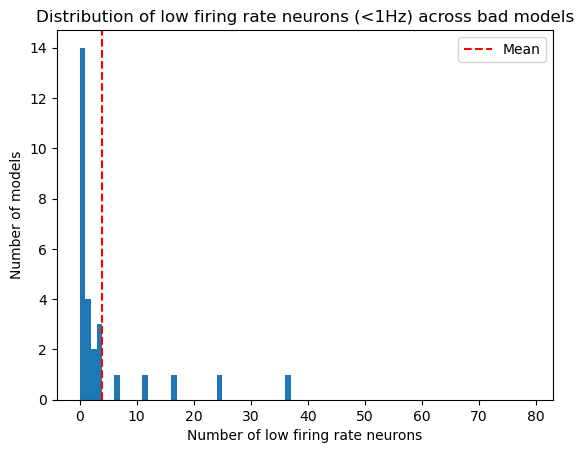

In [16]:
plt.hist(n_lowfr_1, bins=np.arange(0, 80, 1))
plt.xlabel('Number of low firing rate neurons')
plt.ylabel('Number of models')
plt.title('Distribution of low firing rate neurons (<1Hz) across bad models')
plt.axvline(np.mean(n_lowfr_1), color='red', linestyle='--', label='Mean')
plt.legend()
plt.show()

### threshold 0.5Hz

In [18]:
n_lowfr_1 = np.zeros(len(bad_models))
n_lowfr_2 = np.zeros(len(bad_models))
n_lowfr_half = np.zeros(len(bad_models))
for i_model, model_name in enumerate(bad_models):
    _, spk_df, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                    load_LFP=False, load_spikes=True, load_rates=True)
    times_spk, _,_ = ld.get_times_dict('spk', condn_phrase, condn_num)
    # lowfr_idx = calc_lowfr_neurons(spk_df, times_spk, threshold=1)
    
    n_lowfr_half[i_model] = len(calc_lowfr_neurons(spk_df, times_spk, threshold=0.5))
    n_lowfr_1[i_model] = len(calc_lowfr_neurons(spk_df, times_spk, threshold=1))
    n_lowfr_2[i_model] = len(calc_lowfr_neurons(spk_df, times_spk, threshold=2))
    print(f'{model_name} has {n_lowfr_1[i_model]} low firing rate neurons (<1Hz), {n_lowfr_2[i_model]} low firing rate neurons (<2Hz), and {n_lowfr_half[i_model]} low firing rate neurons (<0.5Hz)')
    
    # fig, axs = plt.subplots(3,5, figsize=(15, 6))
    # axs = axs.flatten()
    # for i, i_neuron in enumerate(lowfr_idx):
    #     if i >= len(axs):
    #         continue
    #     sn.plot_neuron_rates(model_name, i_neuron, condn_phrase, condn_num, rates_data=rates_data, ax=axs[i])
    # plt.suptitle(f'{model_name} low firing rate neurons')
    # plt.tight_layout()
    # plt.show()

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645 has 3.0 low firing rate neurons (<1Hz), 22.0 low firing rate neurons (<2Hz), and 0.0 low firing rate neurons (<0.5Hz)
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926 has 0.0 low firing rate neurons (<1Hz), 4.0 low firing rate neurons (<2Hz), and 0.0 low firing rate neurons (<0.5Hz)
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648 has 1.0 low firing rate neurons (<1Hz), 12.0 low firing rate neurons (<2Hz), and 0.0 low firing rate neurons (<0.5Hz)
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449 has 0.0 low firing rate neurons (<1Hz), 12.0 low firing rate neurons (<2Hz), and 0.0 low firing rate neurons (<0.5Hz)
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_040139 has 0.0 low firing rate neurons (<1Hz), 10.0 low firing rate neurons (<2Hz), and 0.0 low firing rate neurons (<0.5Hz)
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032959 has 11.0 low firing rate neurons (<1Hz), 38.0 low firing 

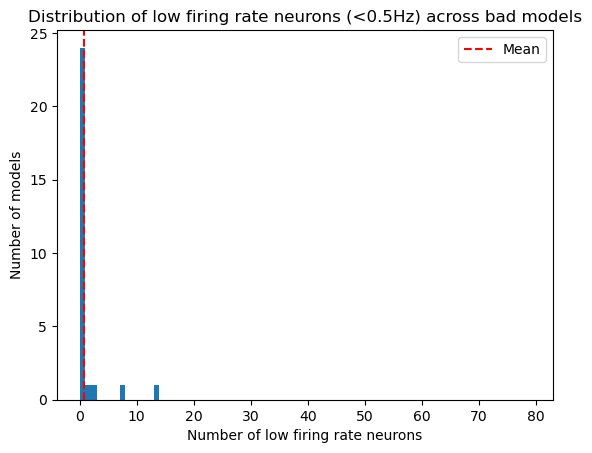

In [19]:
plt.hist(n_lowfr_half, bins=np.arange(0, 80, 1))
plt.xlabel('Number of low firing rate neurons')
plt.ylabel('Number of models')
plt.title('Distribution of low firing rate neurons (<0.5Hz) across bad models')
plt.axvline(np.mean(n_lowfr_half), color='red', linestyle='--', label='Mean')
plt.legend()
plt.show()

## look at model with v low fr

In [21]:
model_name = 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_191340'

### delay 150

In [22]:
_, spk_df, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num=150,
                                                    load_LFP=False, load_spikes=True, load_rates=True)
times_spk, _,_ = ld.get_times_dict('spk', condn_phrase, condn_num)

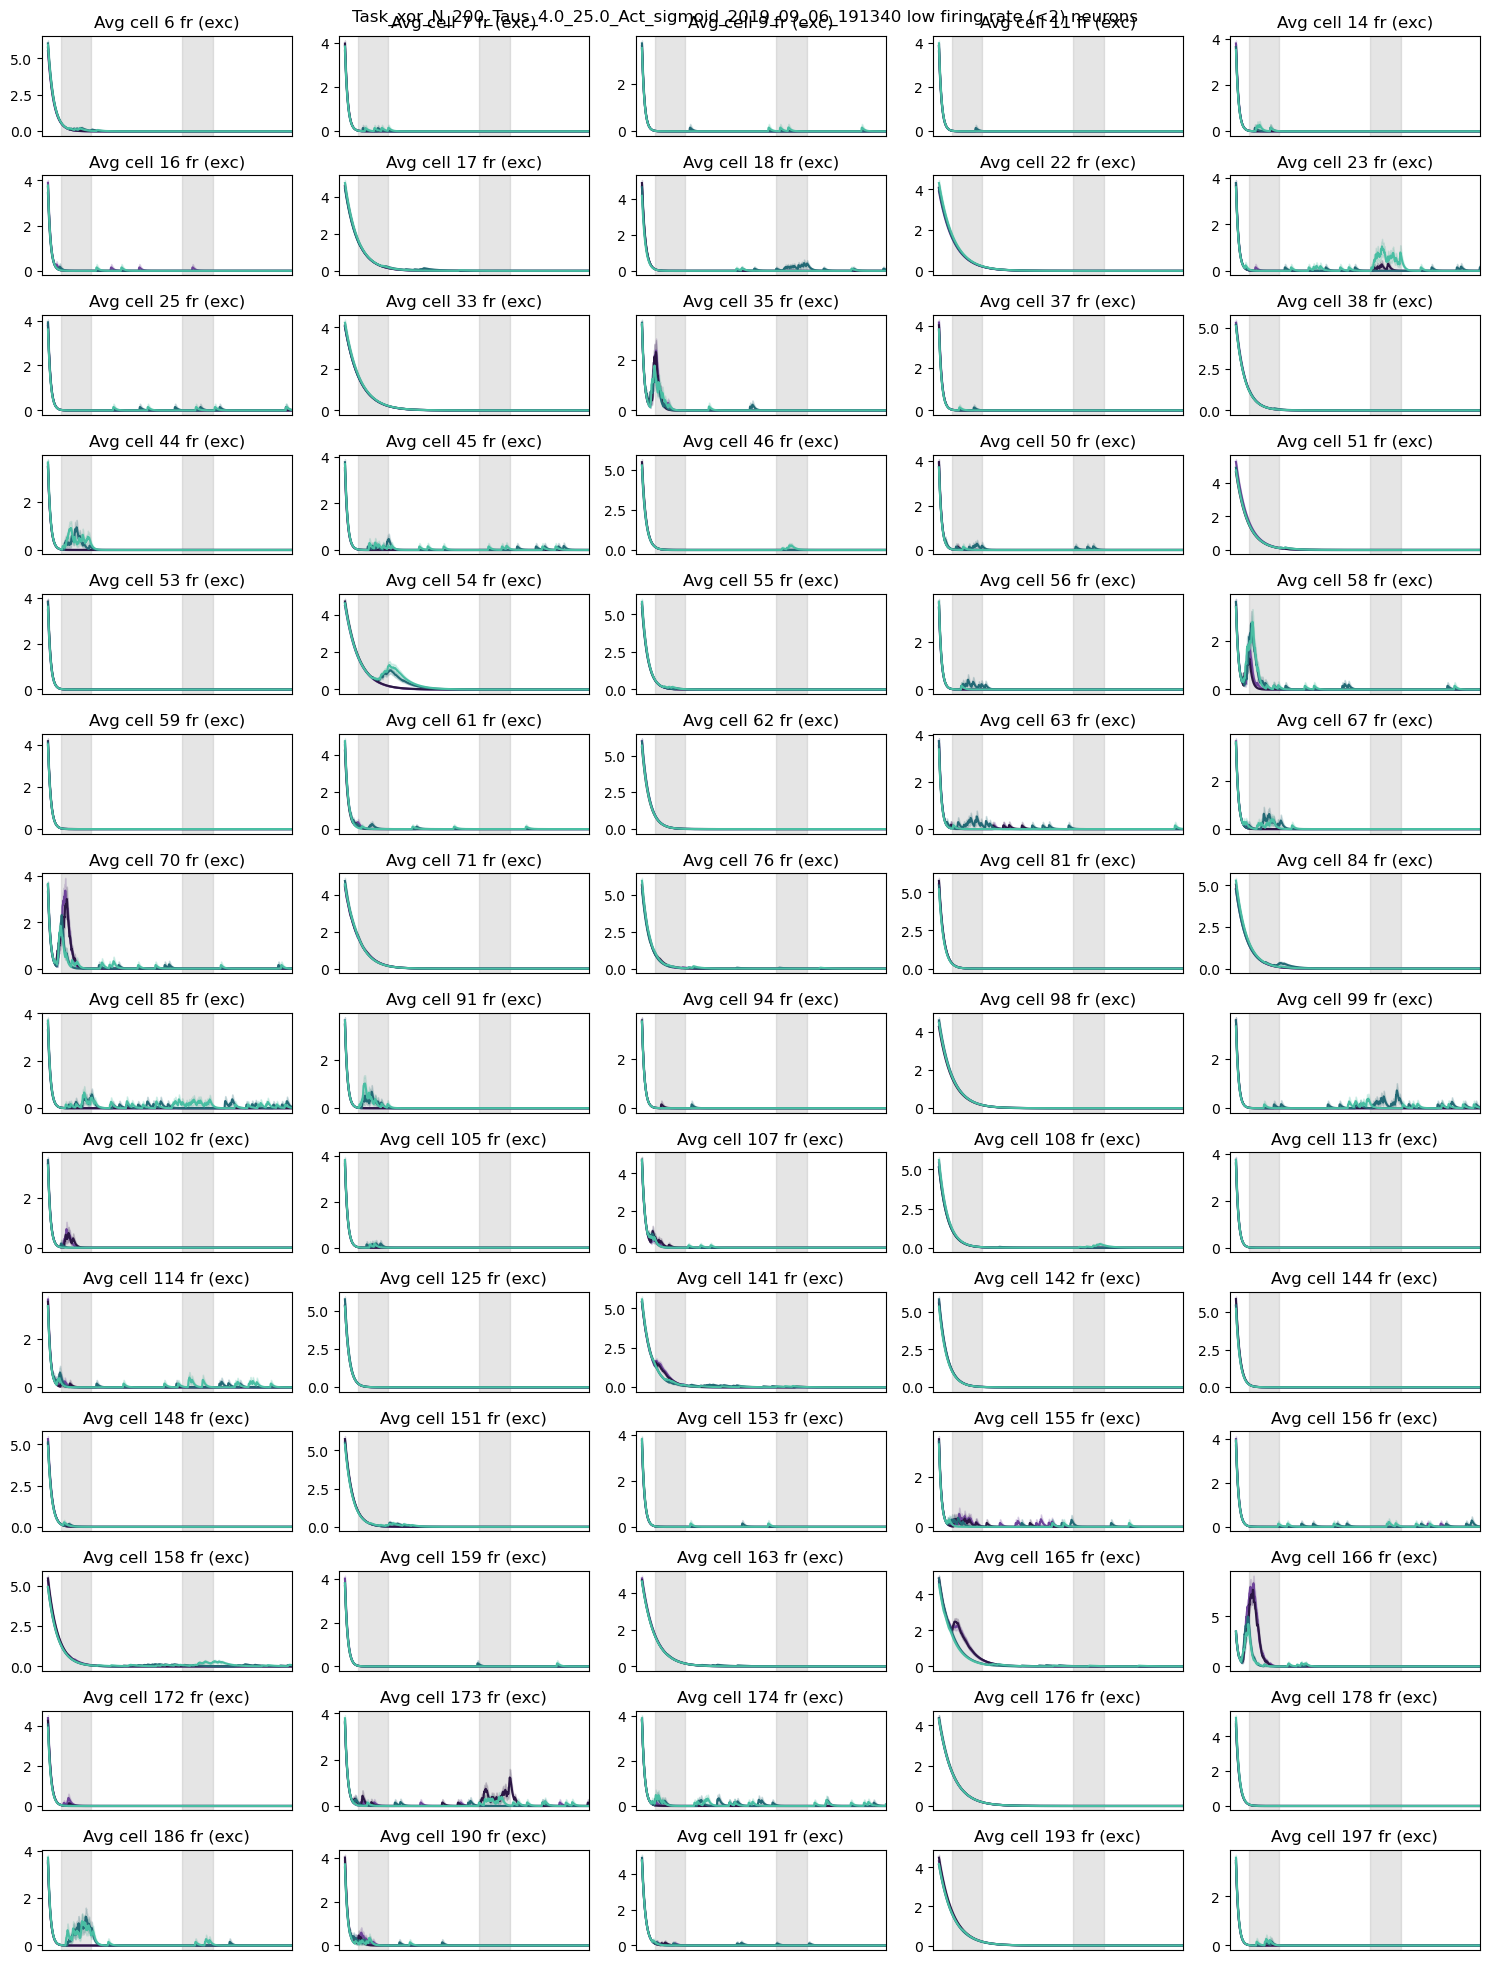

In [33]:
threshold = 2

lowfr_idx = calc_lowfr_neurons(spk_df, times_spk, threshold=threshold)

fig, axs = plt.subplots(14,5, figsize=(15, 20))
axs = axs.flatten()
for i, i_neuron in enumerate(lowfr_idx):
    sn.plot_neuron_rates(model_name, i_neuron, condn_phrase, condn_num, rates_data=rates_data, ax=axs[i])
    # turn off legend
    axs[i].legend().set_visible(False)
    axs[i].set_ylabel('')
    axs[i].set_xlabel('')
    axs[i].set_xticks([])
plt.suptitle(f'{model_name} low firing rate (<{threshold}) neurons')
plt.tight_layout()
plt.show()

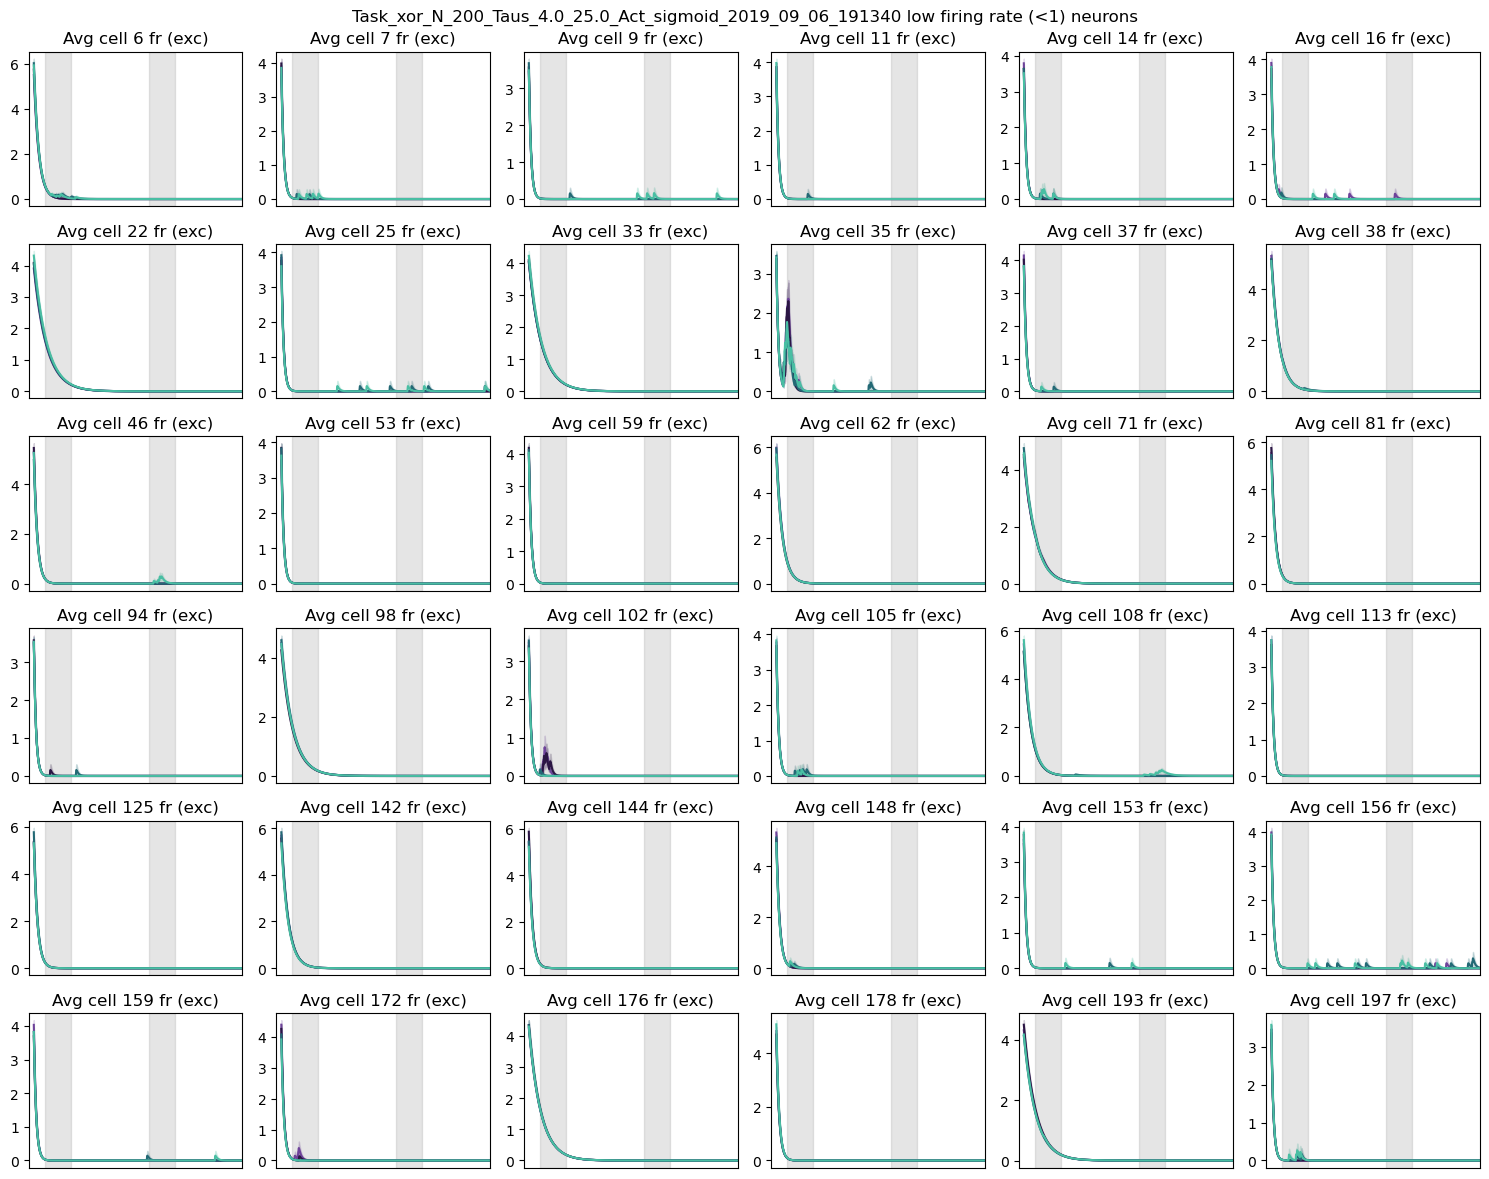

In [34]:
threshold = 1

lowfr_idx = calc_lowfr_neurons(spk_df, times_spk, threshold=threshold)

fig, axs = plt.subplots(6,6, figsize=(15, 12))
axs = axs.flatten()
for i, i_neuron in enumerate(lowfr_idx):
    sn.plot_neuron_rates(model_name, i_neuron, condn_phrase, condn_num, rates_data=rates_data, ax=axs[i])
    # turn off legend
    axs[i].legend().set_visible(False)
    axs[i].set_ylabel('')
    axs[i].set_xlabel('')
    axs[i].set_xticks([])
    # axs[i].set_yticks([])
plt.suptitle(f'{model_name} low firing rate (<{threshold}) neurons')
plt.tight_layout()
plt.show()

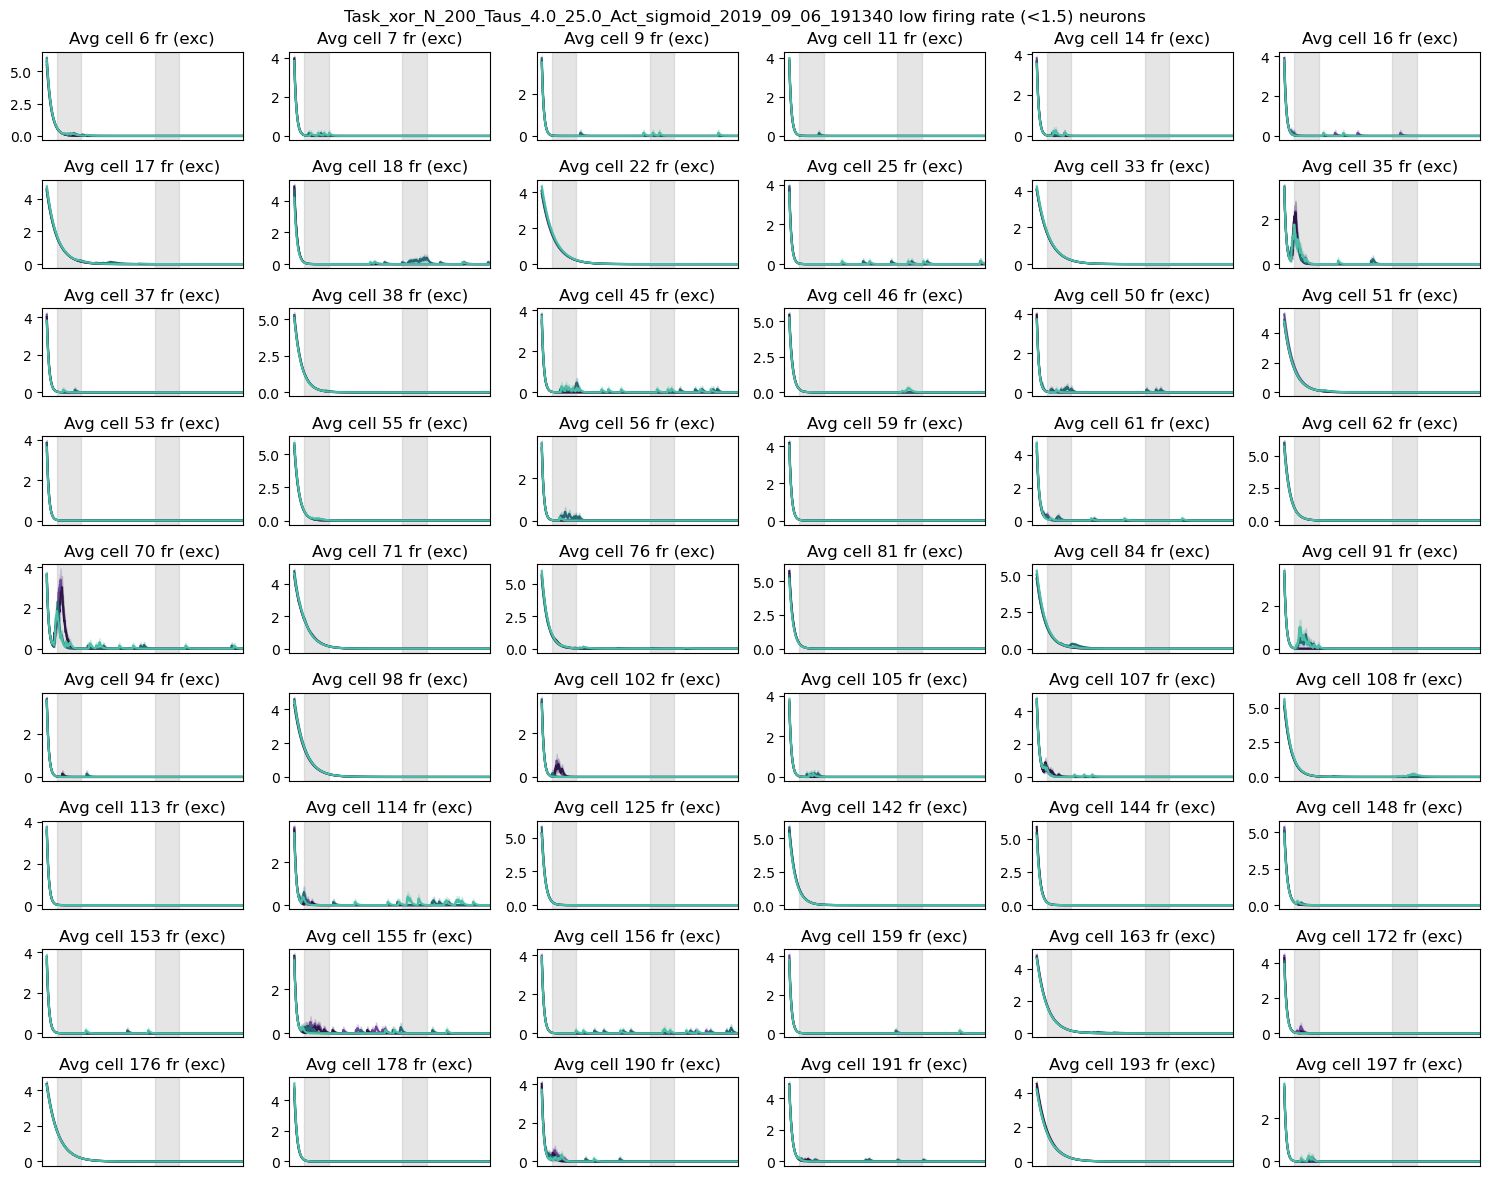

In [37]:
threshold = 1.5

lowfr_idx = calc_lowfr_neurons(spk_df, times_spk, threshold=threshold)

fig, axs = plt.subplots(9,6, figsize=(15, 12))
axs = axs.flatten()
for i, i_neuron in enumerate(lowfr_idx):
    sn.plot_neuron_rates(model_name, i_neuron, condn_phrase, condn_num, rates_data=rates_data, ax=axs[i])
    # turn off legend
    axs[i].legend().set_visible(False)
    axs[i].set_ylabel('')
    axs[i].set_xlabel('')
    axs[i].set_xticks([])
    # axs[i].set_yticks([])
plt.suptitle(f'{model_name} low firing rate (<{threshold}) neurons')
plt.tight_layout()
plt.show()

### delay 50

In [23]:
_, spk_df, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num=50,
                                                    load_LFP=False, load_spikes=True, load_rates=True)
times_spk, _,_ = ld.get_times_dict('spk', condn_phrase, condn_num)

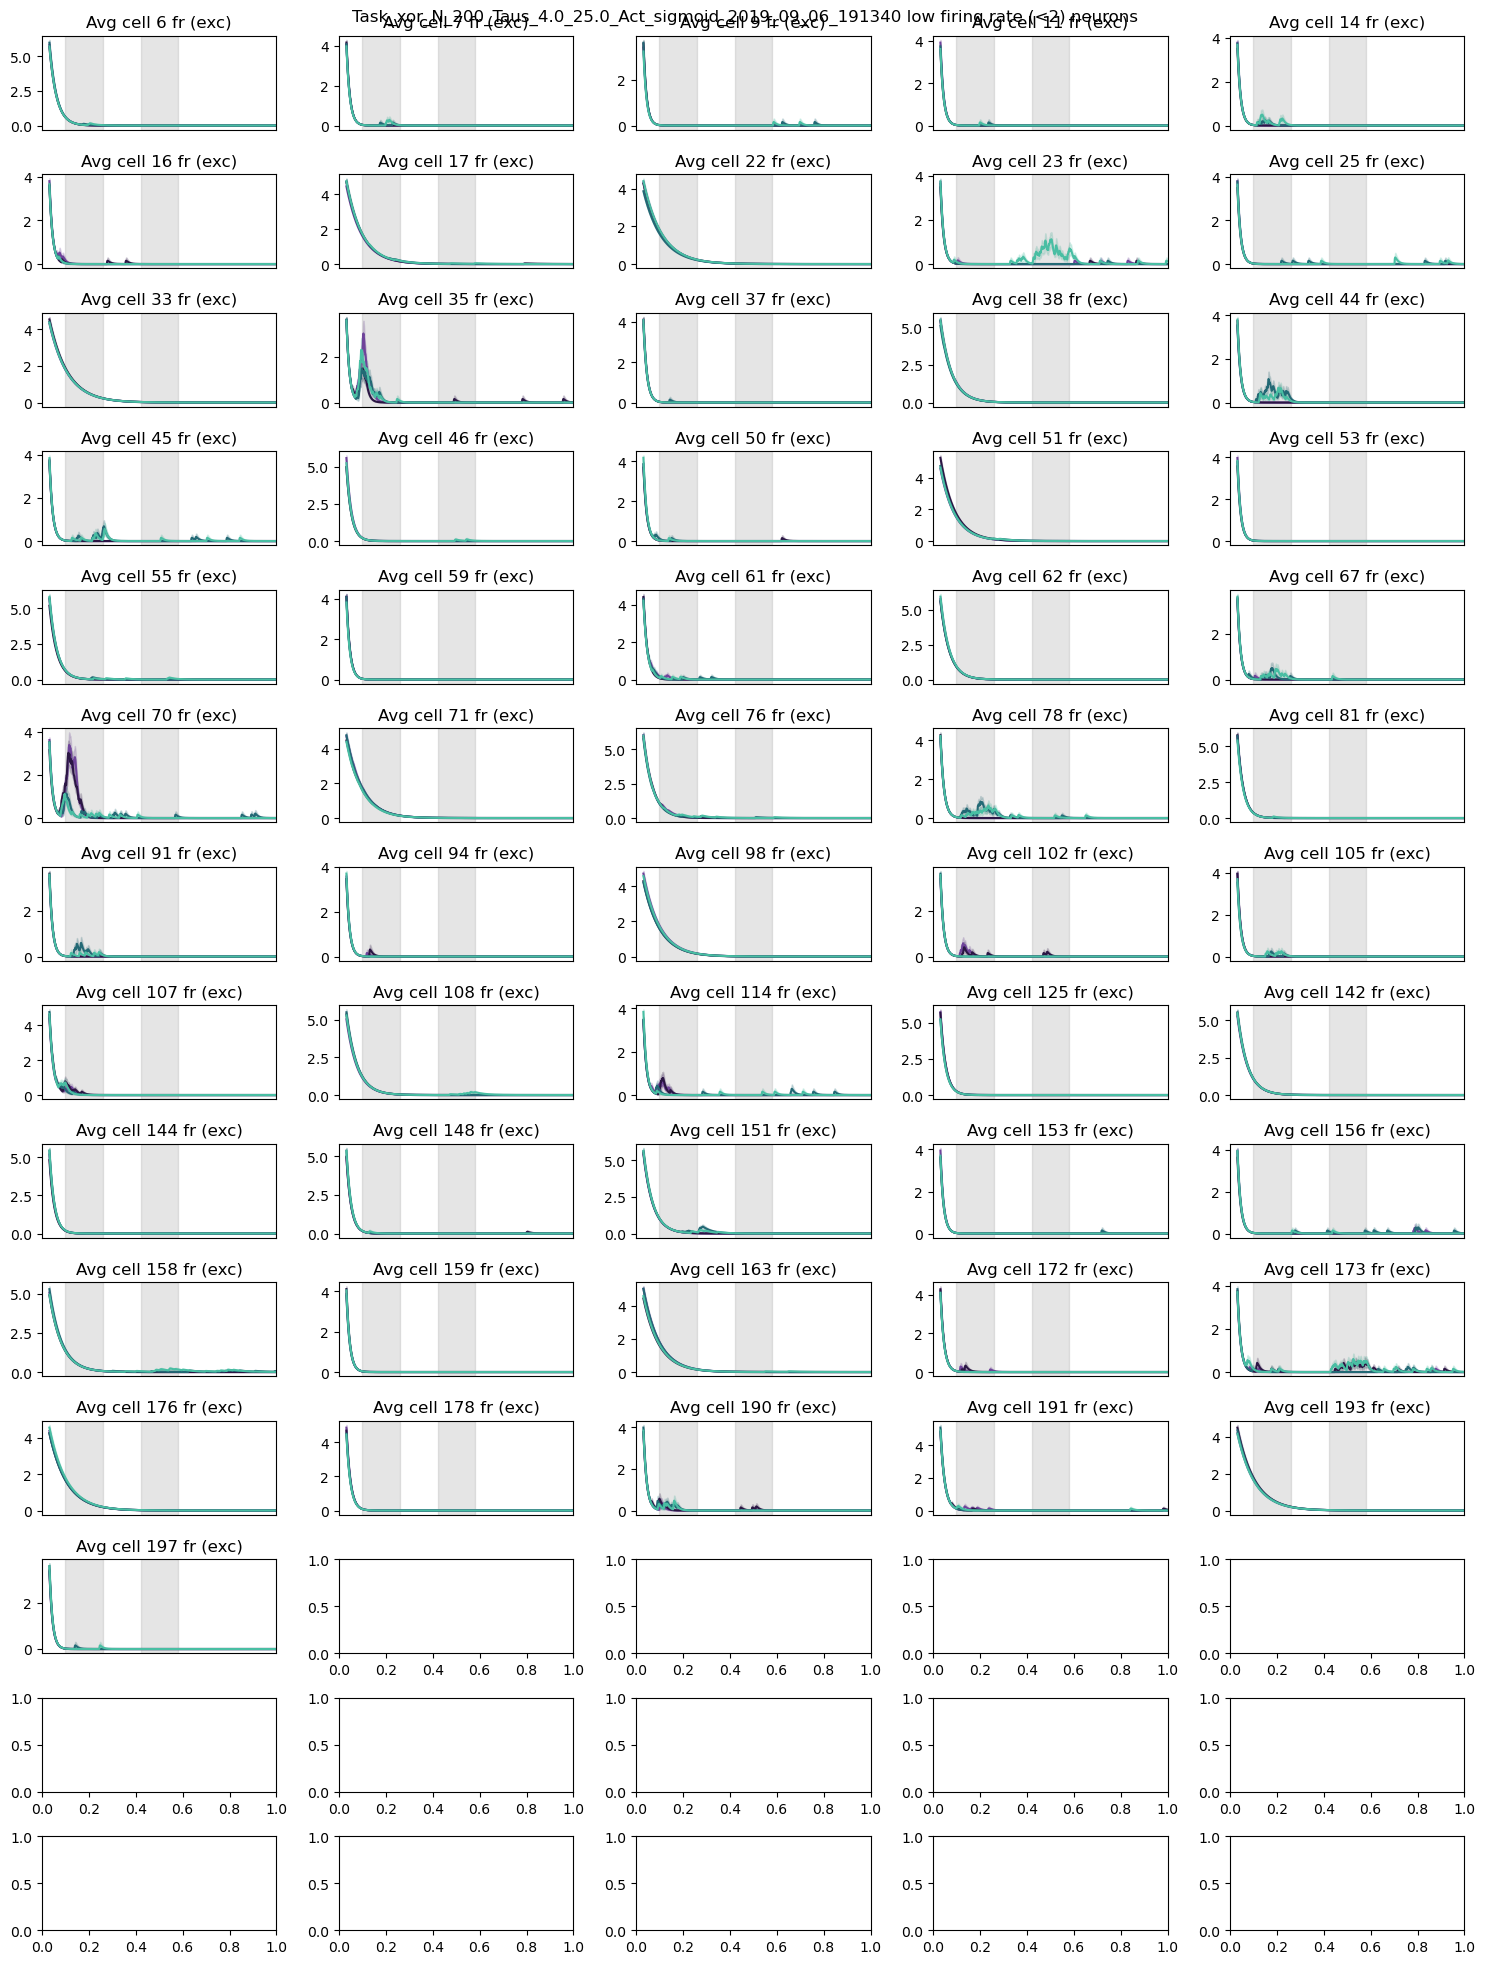

In [24]:
threshold = 2

lowfr_idx = calc_lowfr_neurons(spk_df, times_spk, threshold=threshold)

fig, axs = plt.subplots(14,5, figsize=(15, 20))
axs = axs.flatten()
for i, i_neuron in enumerate(lowfr_idx):
    sn.plot_neuron_rates(model_name, i_neuron, condn_phrase, condn_num, rates_data=rates_data, ax=axs[i])
    # turn off legend
    axs[i].legend().set_visible(False)
    axs[i].set_ylabel('')
    axs[i].set_xlabel('')
    axs[i].set_xticks([])
plt.suptitle(f'{model_name} low firing rate (<{threshold}) neurons')
plt.tight_layout()
plt.show()

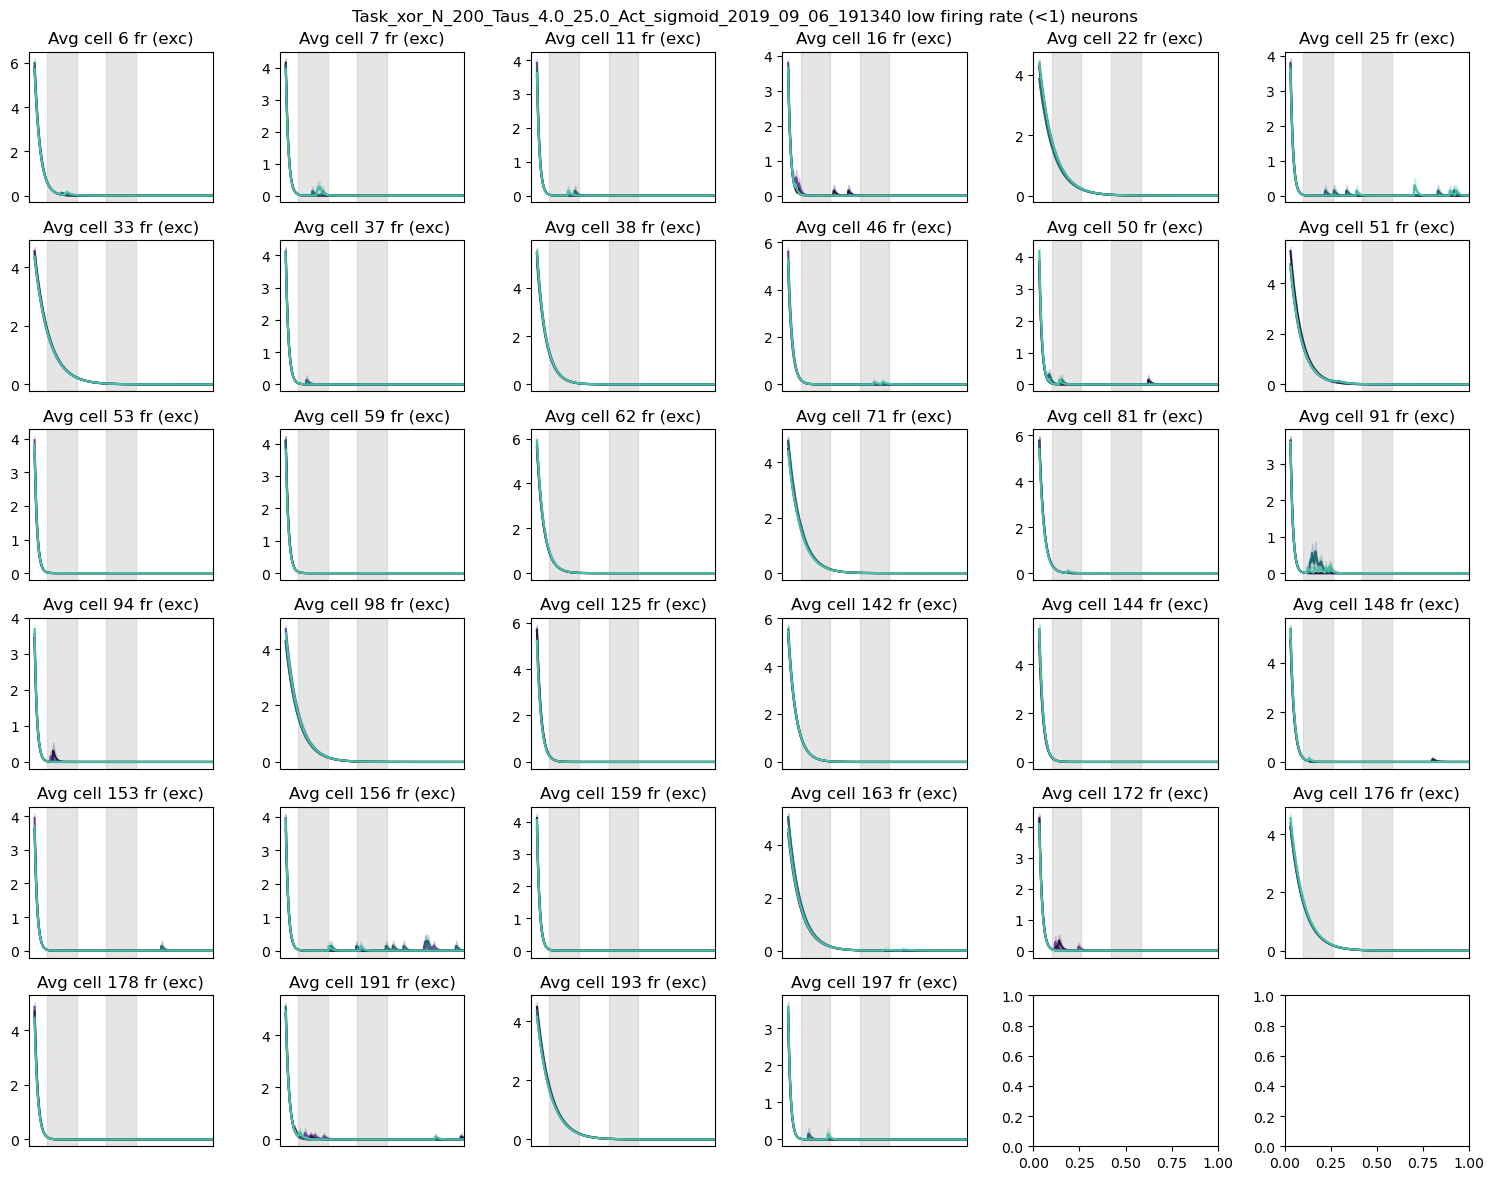

In [25]:
threshold = 1

lowfr_idx = calc_lowfr_neurons(spk_df, times_spk, threshold=threshold)

fig, axs = plt.subplots(6,6, figsize=(15, 12))
axs = axs.flatten()
for i, i_neuron in enumerate(lowfr_idx):
    sn.plot_neuron_rates(model_name, i_neuron, condn_phrase, condn_num, rates_data=rates_data, ax=axs[i])
    # turn off legend
    axs[i].legend().set_visible(False)
    axs[i].set_ylabel('')
    axs[i].set_xlabel('')
    axs[i].set_xticks([])
    # axs[i].set_yticks([])
plt.suptitle(f'{model_name} low firing rate (<{threshold}) neurons')
plt.tight_layout()
plt.show()

IndexError: index 54 is out of bounds for axis 0 with size 54

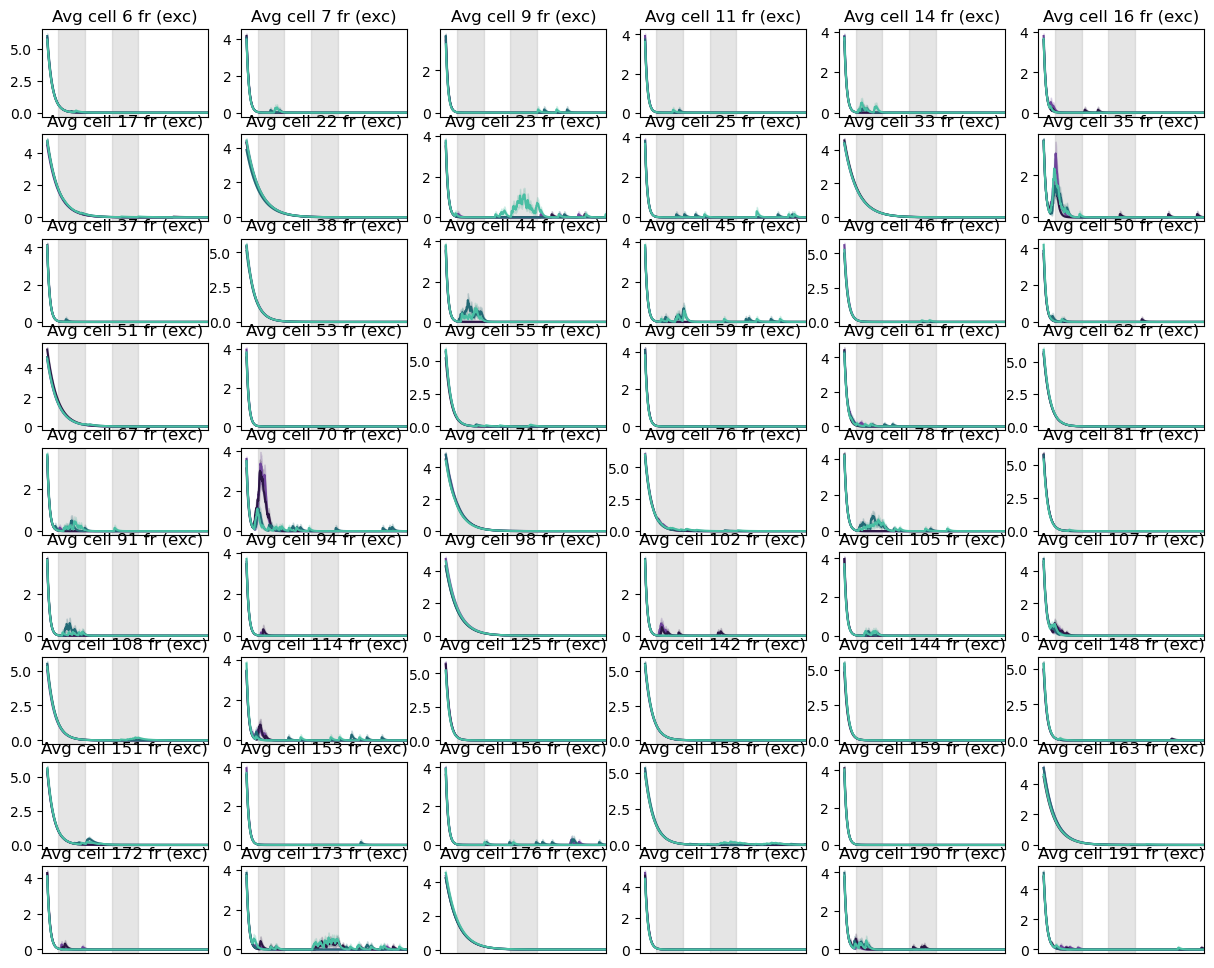

In [26]:
threshold = 1.5

lowfr_idx = calc_lowfr_neurons(spk_df, times_spk, threshold=threshold)

fig, axs = plt.subplots(9,6, figsize=(15, 12))
axs = axs.flatten()
for i, i_neuron in enumerate(lowfr_idx):
    sn.plot_neuron_rates(model_name, i_neuron, condn_phrase, condn_num, rates_data=rates_data, ax=axs[i])
    # turn off legend
    axs[i].legend().set_visible(False)
    axs[i].set_ylabel('')
    axs[i].set_xlabel('')
    axs[i].set_xticks([])
    # axs[i].set_yticks([])
plt.suptitle(f'{model_name} low firing rate (<{threshold}) neurons')
plt.tight_layout()
plt.show()